In [2]:
import os

import numpy as np
from werkzeug.serving import can_fork

from transform_dataset import *
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

Index(['ALGO', 'AENO', 'LSST', 'SRNA', 'ELLT', 'AMRP', 'OTCS', 'HETT', 'HUXZ',
       'DUCT', 'SMAH', 'NPCK', 'MSDP', 'EORC', 'CUBO', 'HRET', 'ANSO', 'DIHO',
       'RTTH', 'SPLZ', 'NWIG', 'MMBT', 'MDGI', 'AGVF', 'RRES', 'CTGI', 'ALUT',
       'ACAC', 'SRTX', 'GARI', 'RCRI', 'ACIX', 'CCNS', 'MTNS', 'IHOZ', 'NAYO',
       'FWWG', 'EELT', 'HRND', 'AETS', 'ULXY', 'BLBT', 'BENI', 'ITPA', 'HTRK',
       'NGTE', 'ILVX', 'FCSG', 'FARS', 'MHRM', 'EAFC'],
      dtype='str')


Load in Data

In [3]:
prices = load_dataset('prices.csv')
prices

,ALGO,AENO,LSST,SRNA,ELLT,AMRP,OTCS,HETT,HUXZ,DUCT,...,BLBT,BENI,ITPA,HTRK,NGTE,ILVX,FCSG,FARS,MHRM,EAFC
0,100.00,116.51,113.55,134.23,64.12,25.05,14.68,59.24,83.62,19.71,...,52.23,32.37,18.82,10.86,52.65,32.58,27.46,66.43,22.41,45.08
1,98.49,112.94,114.53,133.21,62.74,23.96,14.55,58.28,79.94,19.22,...,52.73,32.25,18.41,10.77,49.71,31.66,26.47,64.66,22.10,44.28
2,97.83,112.70,112.17,132.80,61.61,23.30,14.69,57.97,81.20,19.22,...,53.23,32.23,18.22,10.69,50.53,30.84,25.28,64.19,20.87,45.30
3,98.02,112.26,116.09,133.16,63.55,23.47,14.43,57.02,81.82,19.39,...,52.67,32.20,18.22,10.28,51.64,30.95,24.60,62.80,20.95,46.32
4,99.13,113.59,119.58,137.20,63.64,23.61,14.61,58.78,83.01,19.91,...,53.59,32.33,18.25,10.50,53.57,31.49,25.66,63.94,20.72,45.56
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,120.41,78.94,134.18,71.34,77.93,15.30,22.40,83.24,53.75,10.47,...,37.02,38.30,28.66,13.90,45.86,67.85,33.19,36.82,17.72,39.49
996,120.93,77.04,135.65,70.20,79.34,15.17,21.90,82.89,54.62,10.67,...,36.92,38.00,29.11,13.61,46.57,67.91,33.13,37.51,17.63,39.53
997,120.92,77.59,133.28,70.37,78.65,14.74,22.01,83.08,55.18,10.44,...,36.50,37.67,29.76,13.66,45.20,67.62,33.33,37.84,17.40,39.68
998,118.51,77.73,130.24,68.05,77.87,14.64,22.17,81.36,53.43,10.29,...,35.95,38.05,28.80,13.48,44.99,67.89,32.70,37.18,17.29,39.12


In [4]:
prices.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 51 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   ALGO    1000 non-null   float64
 1   AENO    1000 non-null   float64
 2   LSST    1000 non-null   float64
 3   SRNA    1000 non-null   float64
 4   ELLT    1000 non-null   float64
 5   AMRP    1000 non-null   float64
 6   OTCS    1000 non-null   float64
 7   HETT    1000 non-null   float64
 8   HUXZ    1000 non-null   float64
 9   DUCT    1000 non-null   float64
 10  SMAH    1000 non-null   float64
 11  NPCK    1000 non-null   float64
 12  MSDP    1000 non-null   float64
 13  EORC    1000 non-null   float64
 14  CUBO    1000 non-null   float64
 15  HRET    1000 non-null   float64
 16  ANSO    1000 non-null   float64
 17  DIHO    1000 non-null   float64
 18  RTTH    1000 non-null   float64
 19  SPLZ    1000 non-null   float64
 20  NWIG    1000 non-null   float64
 21  MMBT    1000 non-null   float64
 22  MDGI    1000

In [5]:
print(prices.describe())

              ALGO         AENO         LSST         SRNA         ELLT  \
count  1000.000000  1000.000000  1000.000000  1000.000000  1000.000000   
mean     96.103300    81.232130    90.612370    87.547430    77.716300   
std       9.197768    22.292651    14.674314    32.012435    19.465857   
min      77.200000    52.500000    61.730000    48.390000    42.520000   
25%      88.220000    62.660000    80.440000    59.157500    64.455000   
50%      97.480000    74.285000    87.255000    75.230000    73.325000   
75%     103.685000   101.445000    97.440000   115.272500    94.305000   
max     120.930000   133.520000   140.530000   166.260000   123.030000   

             AMRP         OTCS         HETT         HUXZ        DUCT  ...  \
count  1000.00000  1000.000000  1000.000000  1000.000000  1000.00000  ...   
mean     17.98691    23.835750    66.992570    60.665350    15.12207  ...   
std       3.19974     6.320389     9.844589    13.654475     3.91003  ...   
min      11.55000    12.6

Per Instrument Summary Stats:

In [6]:
for instruments in prices.columns:
    mean = prices[instruments].mean()
    std = prices[instruments].std()
    var = std**2
    median = prices[instruments].median()
    skew = prices[instruments].skew()
    kurtosis = prices[instruments].kurtosis()
    print(f"Instrument Name: {instruments}\n"
          f"Mean: {mean}\n"
          f"Std: {std}\n"
          f"Median : {median}\n"
          f"Std / Mean: {std/mean}\n"
          f"Variance: {var}\n"
          f"Skew: {skew}\n"
          f"Kurtosis: {kurtosis}\n")

Instrument Name: ALGO
Mean: 96.10329999999999
Std: 9.197768188514521
Median : 97.48
Std / Mean: 0.09570710046912564
Variance: 84.5989396496497
Skew: 0.03872519205804018
Kurtosis: -0.8637958775274552

Instrument Name: AENO
Mean: 81.23213
Std: 22.29265064625417
Median : 74.285
Std / Mean: 0.274431442906325
Variance: 496.96227283593646
Skew: 0.7515861492603226
Kurtosis: -0.7969684640467416

Instrument Name: LSST
Mean: 90.61237
Std: 14.674313904631855
Median : 87.255
Std / Mean: 0.16194603346796752
Variance: 215.33548857167182
Skew: 1.1068019517666072
Kurtosis: 0.9357417391256742

Instrument Name: SRNA
Mean: 87.54742999999999
Std: 32.012435035342
Median : 75.23
Std / Mean: 0.3656581927686741
Variance: 1024.795996891992
Skew: 0.609375221621717
Kurtosis: -0.8765627462279455

Instrument Name: ELLT
Mean: 77.71629999999999
Std: 19.46585749248971
Median : 73.325
Std / Mean: 0.250473291863994
Variance: 378.9196079179178
Skew: 0.40941414092625894
Kurtosis: -0.7546358263965787

Instrument Name: AMR

Price Distribution Plots

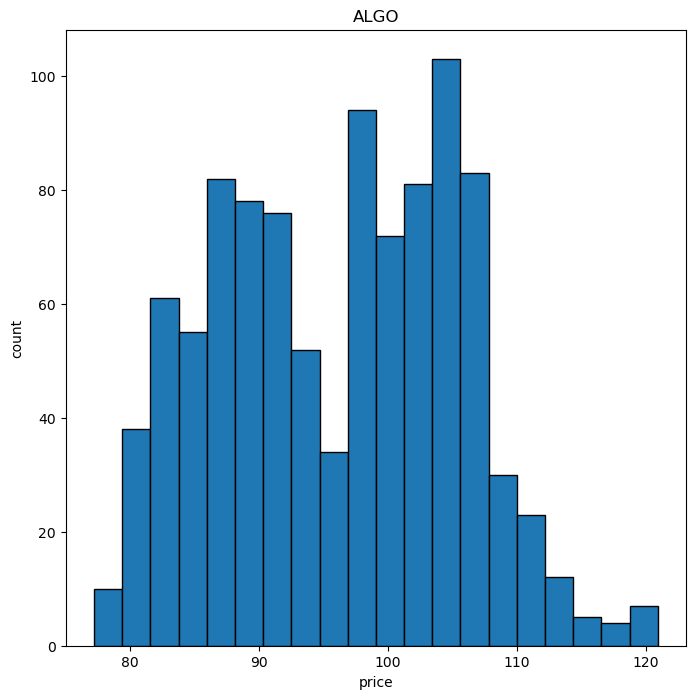

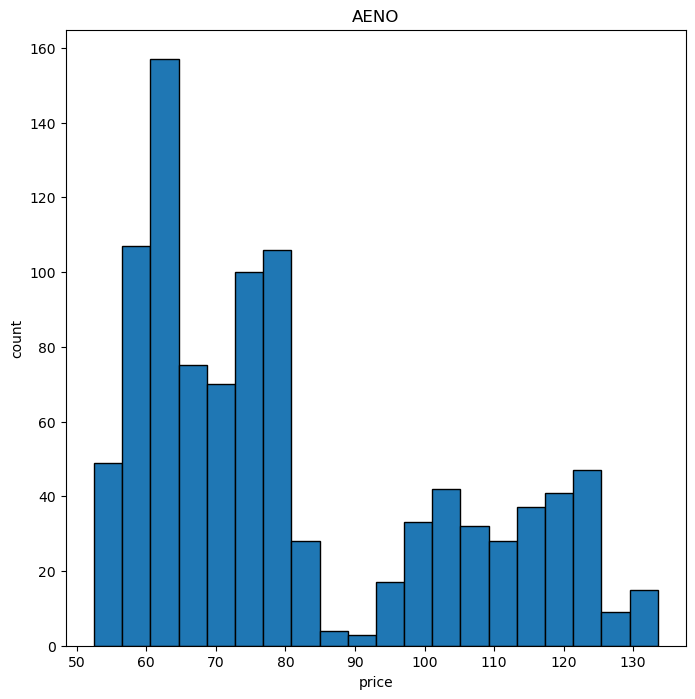

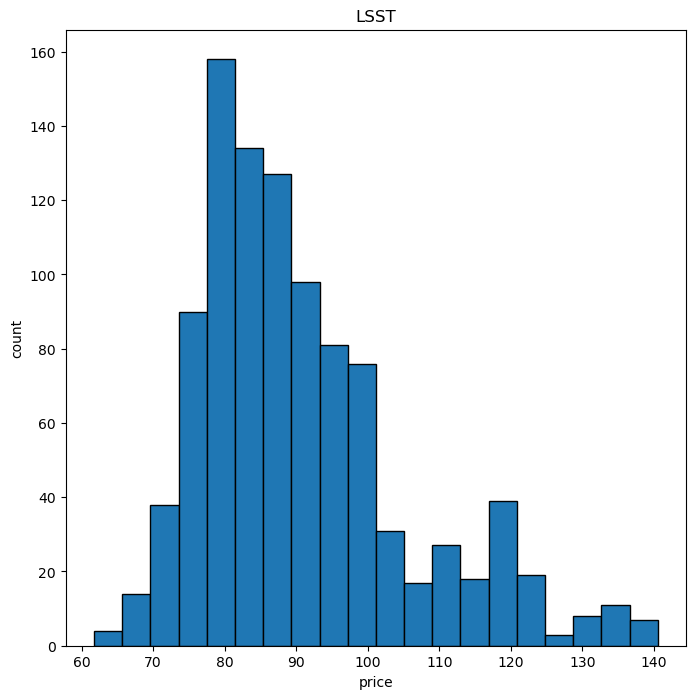

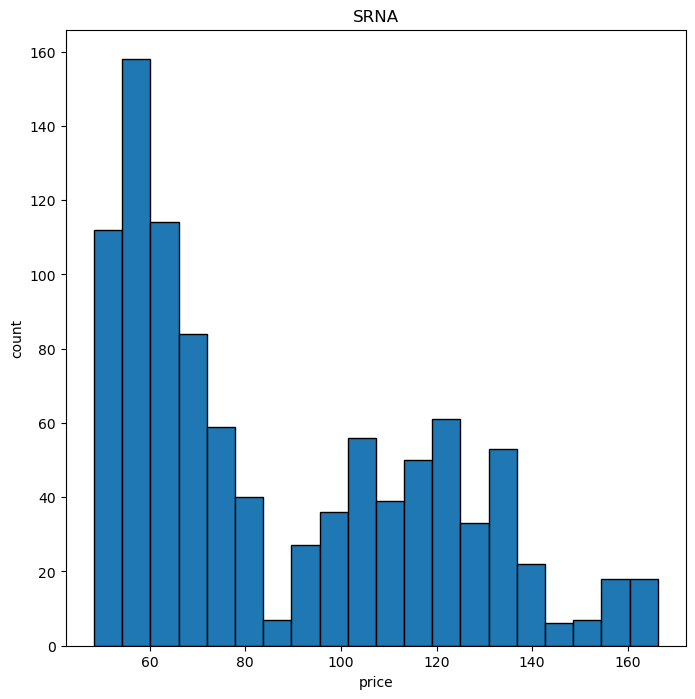

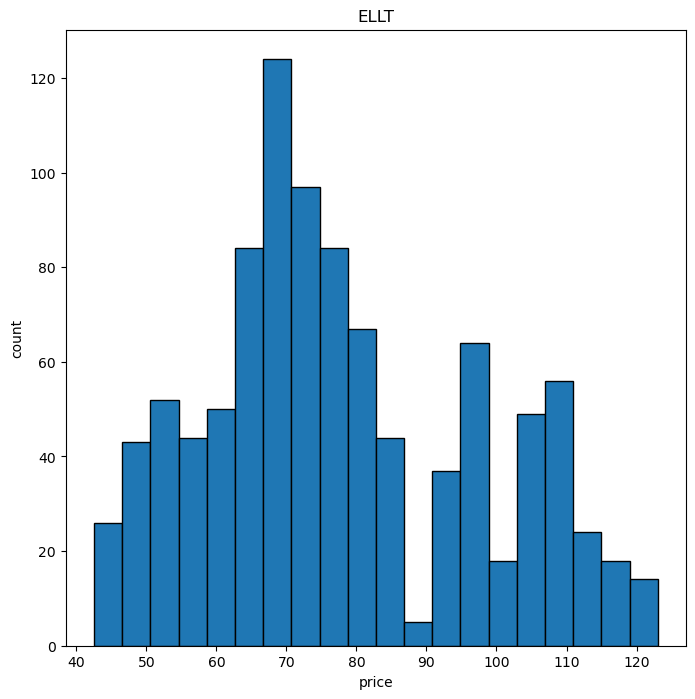

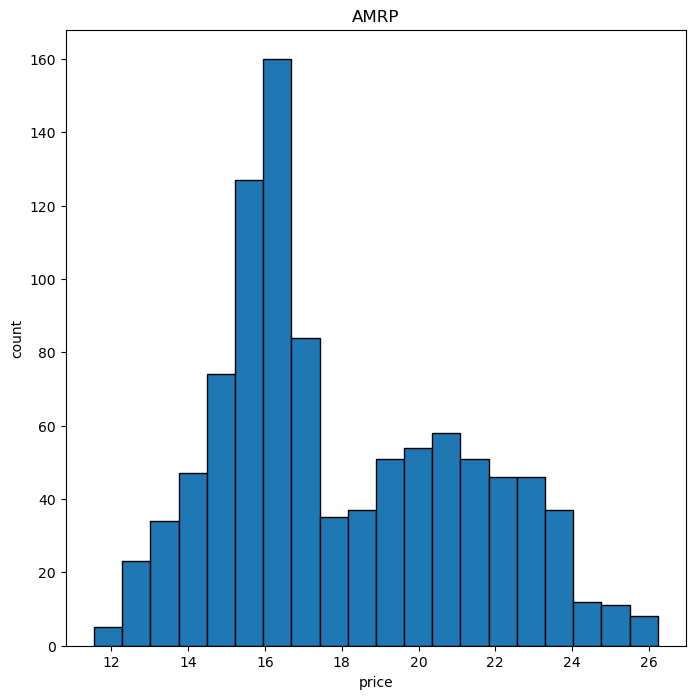

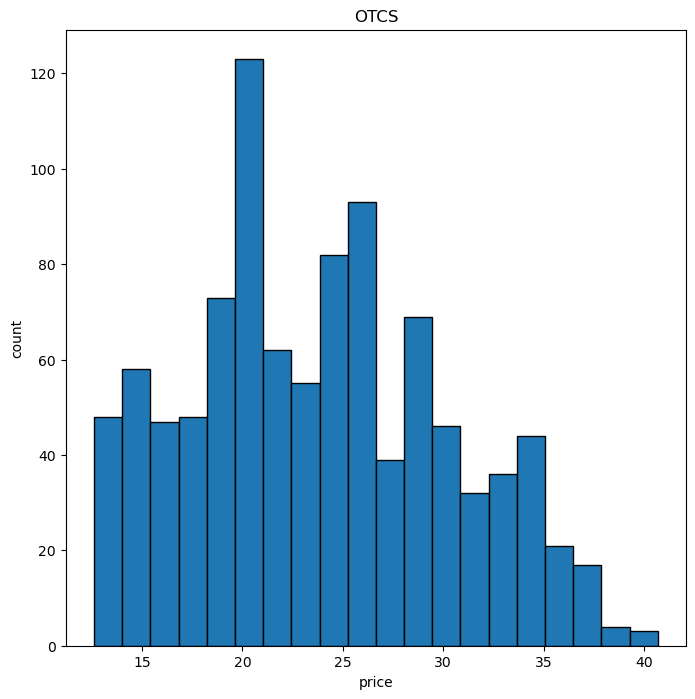

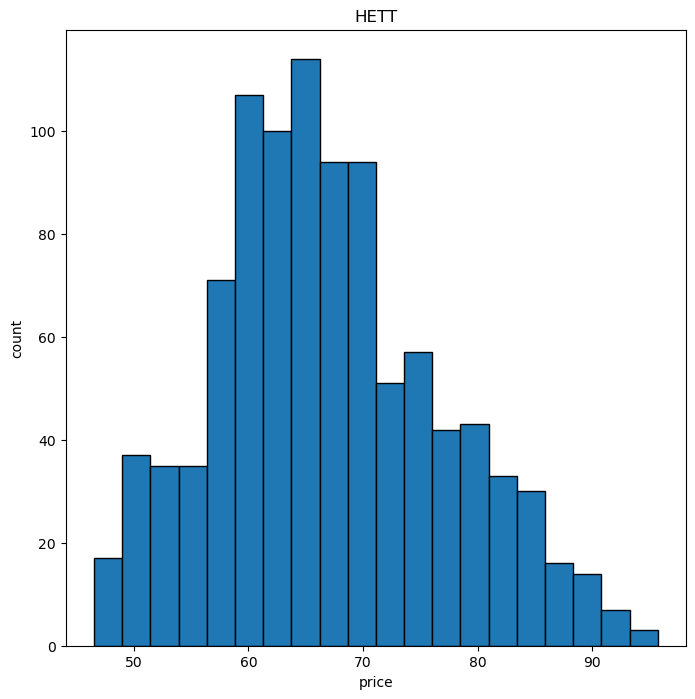

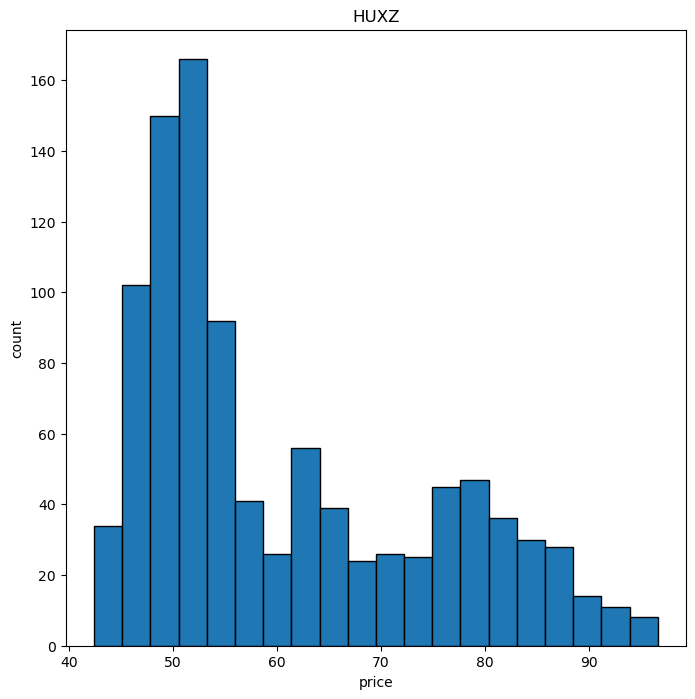

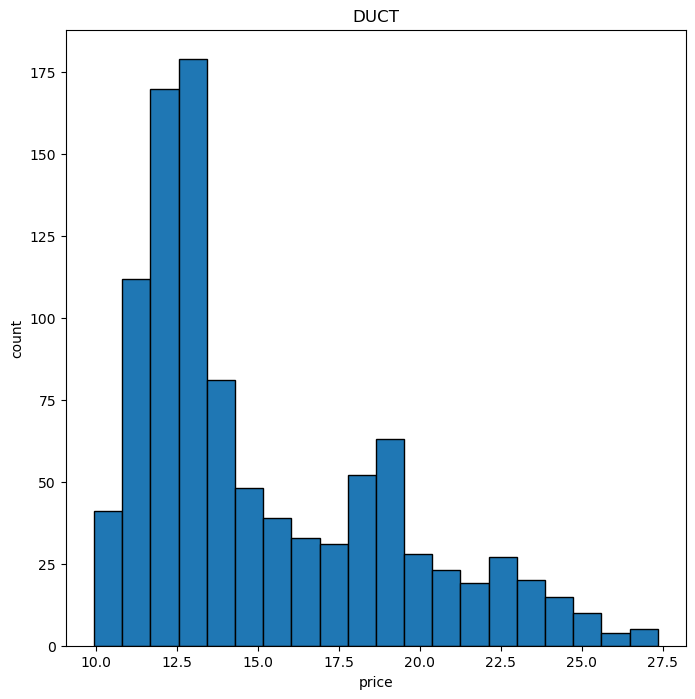

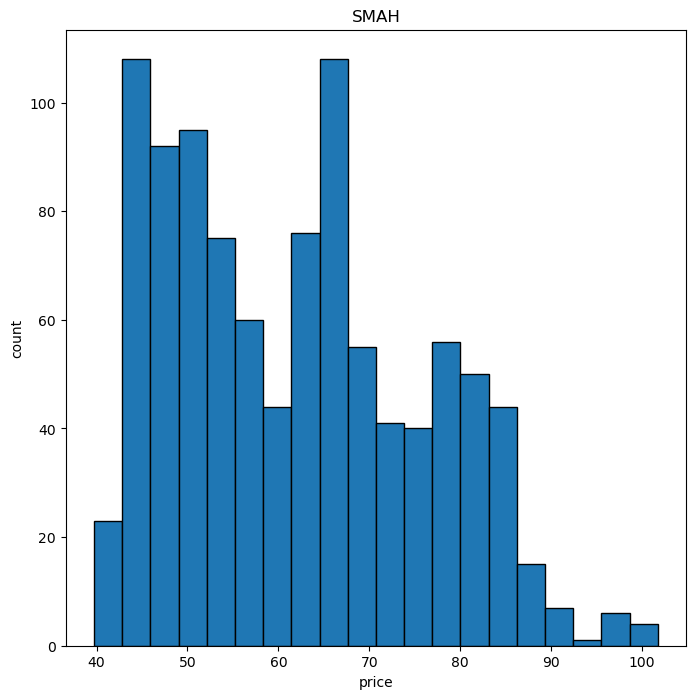

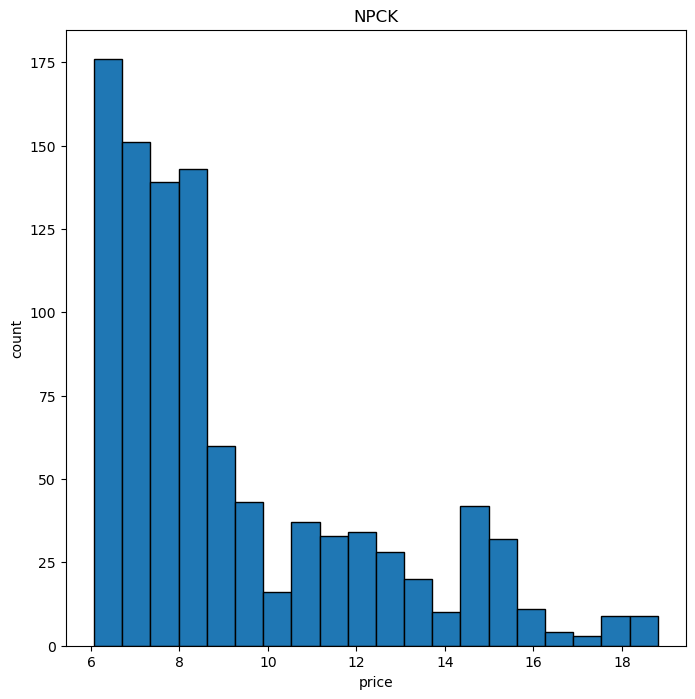

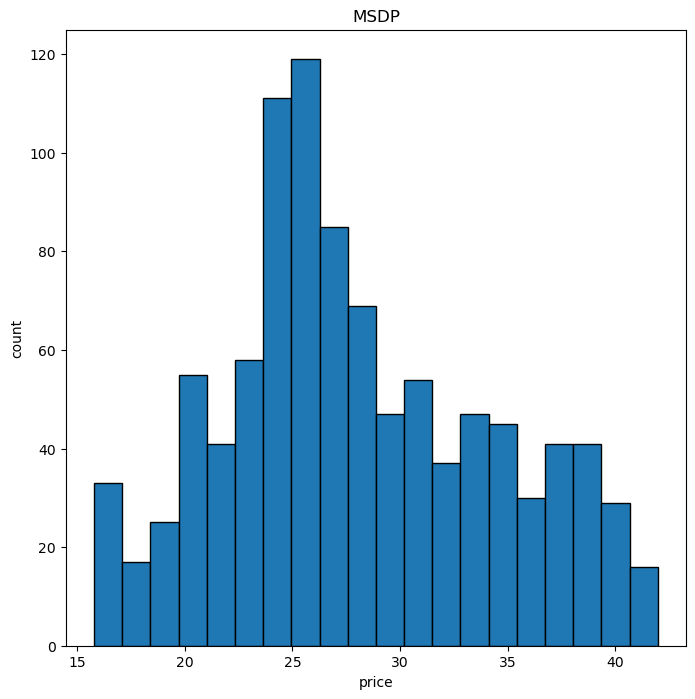

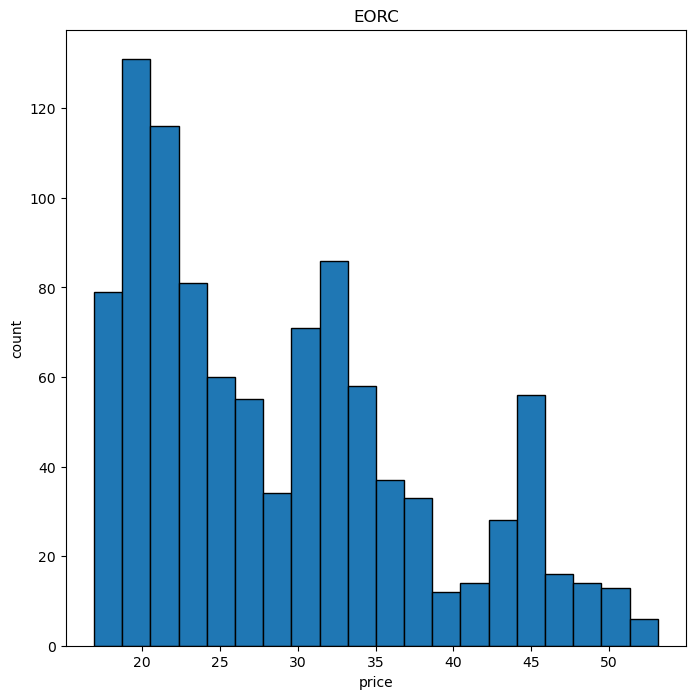

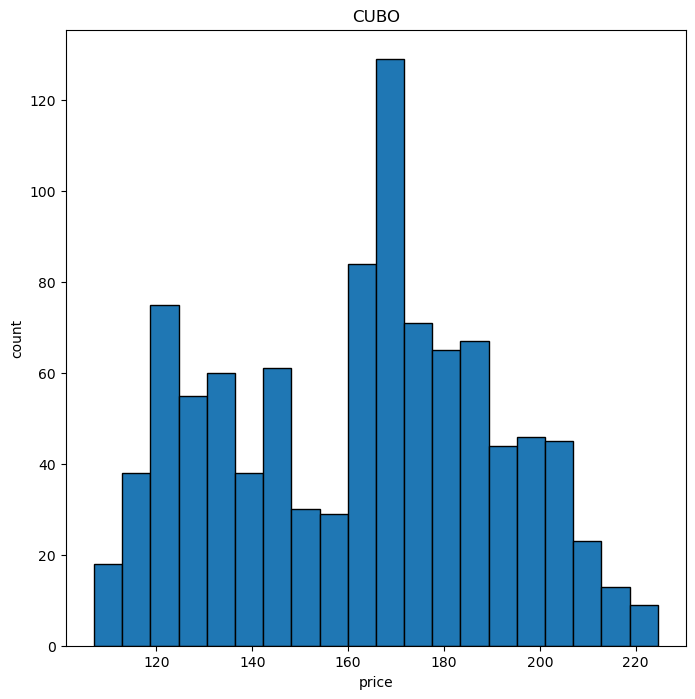

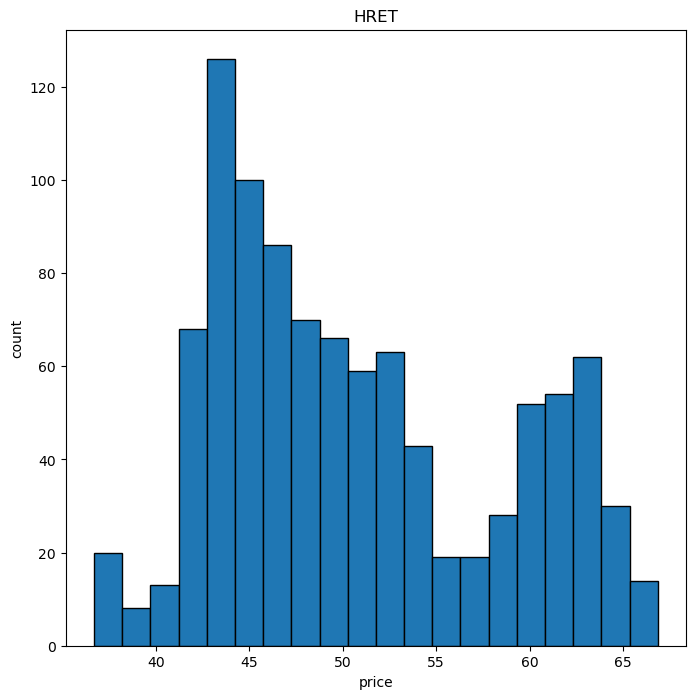

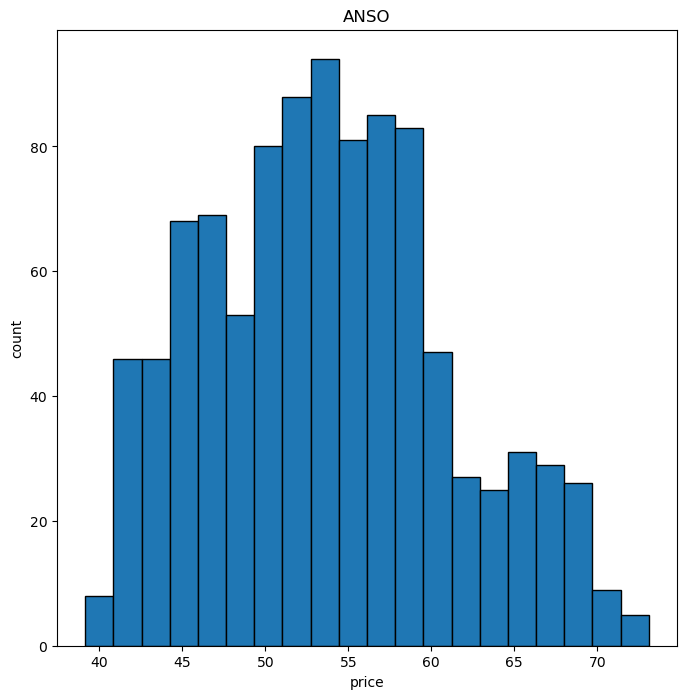

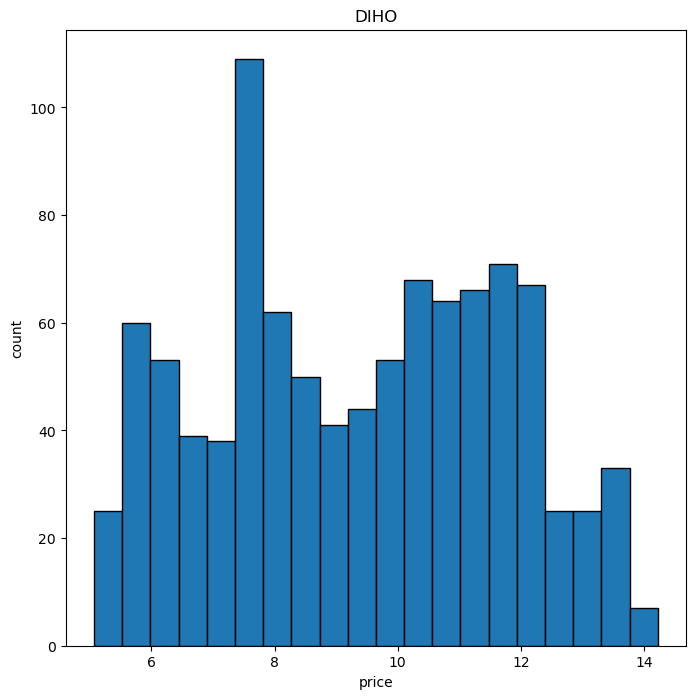

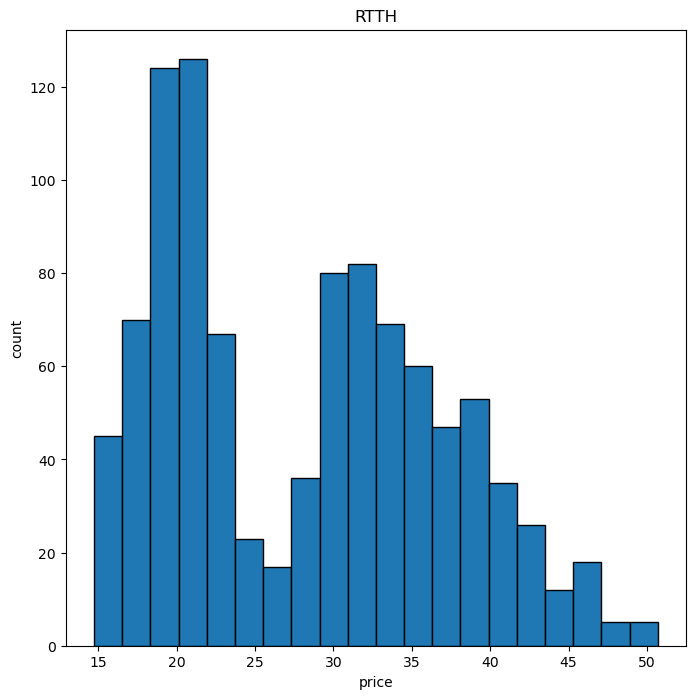

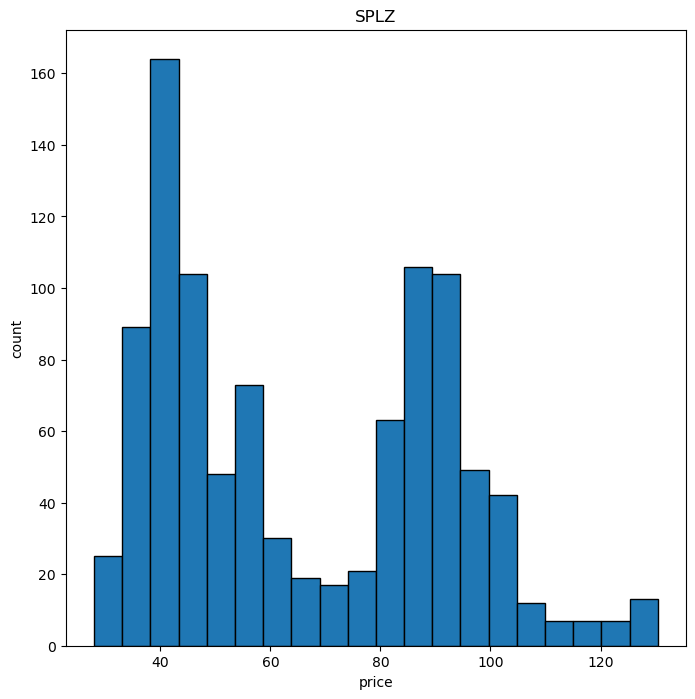

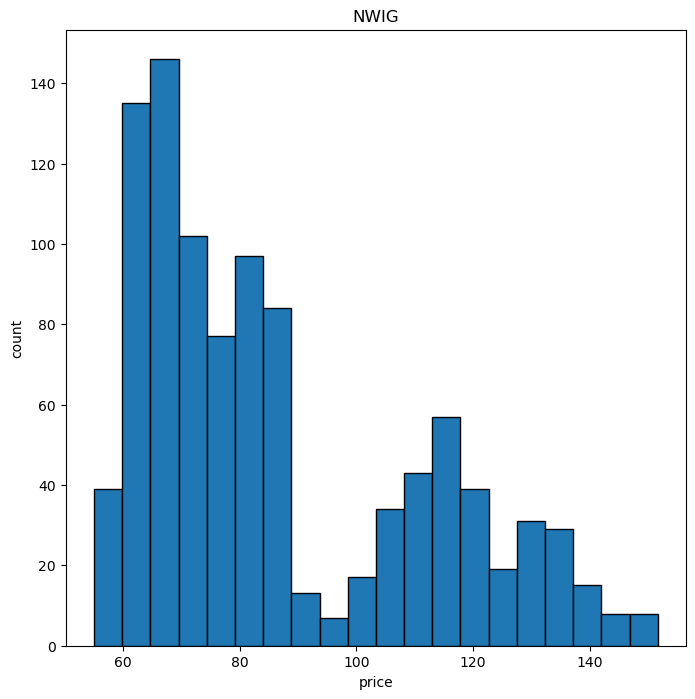

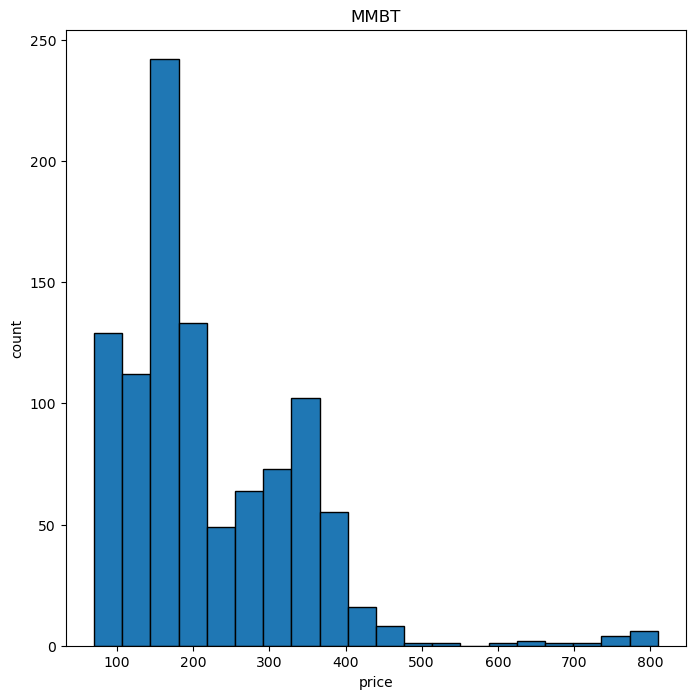

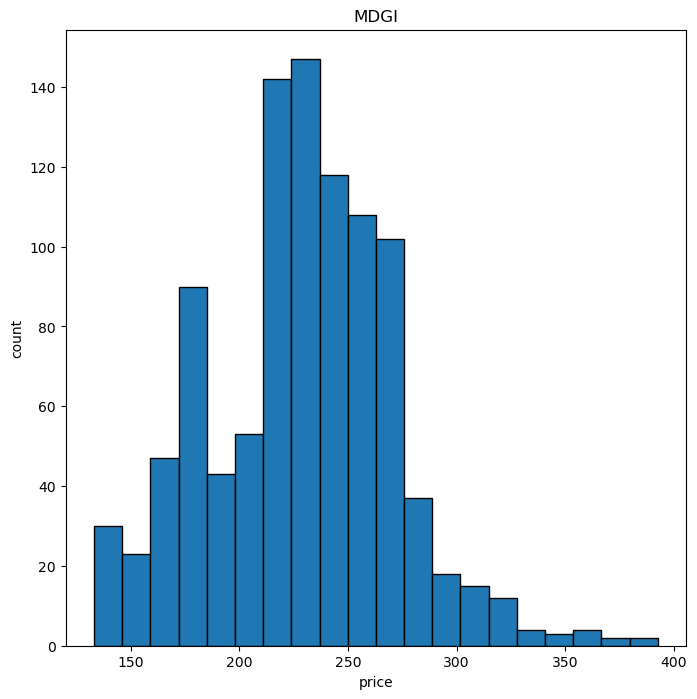

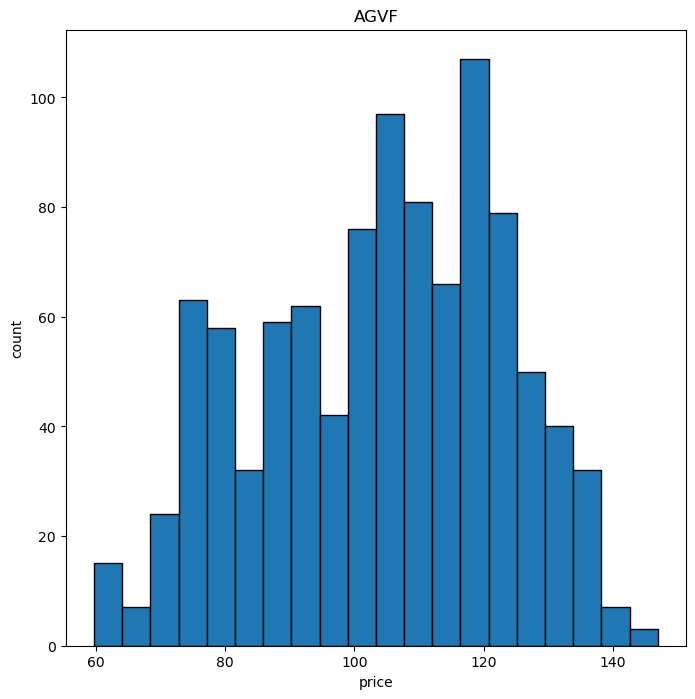

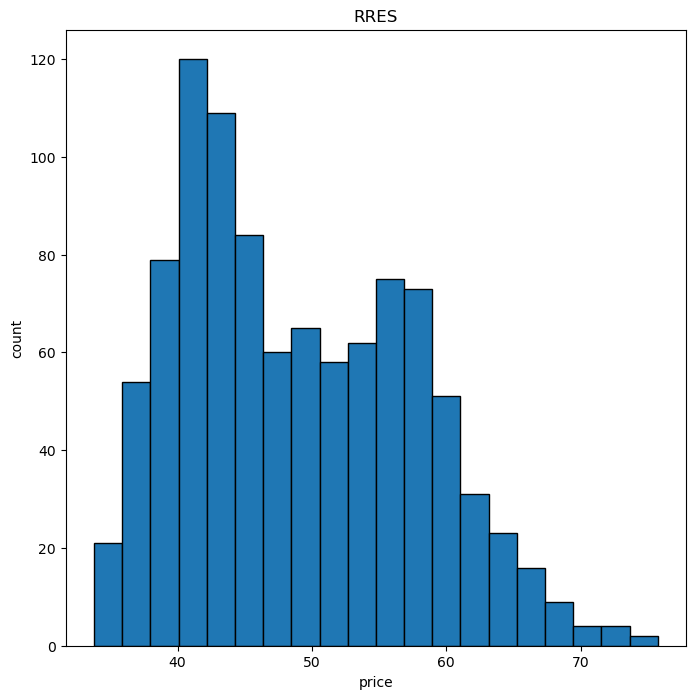

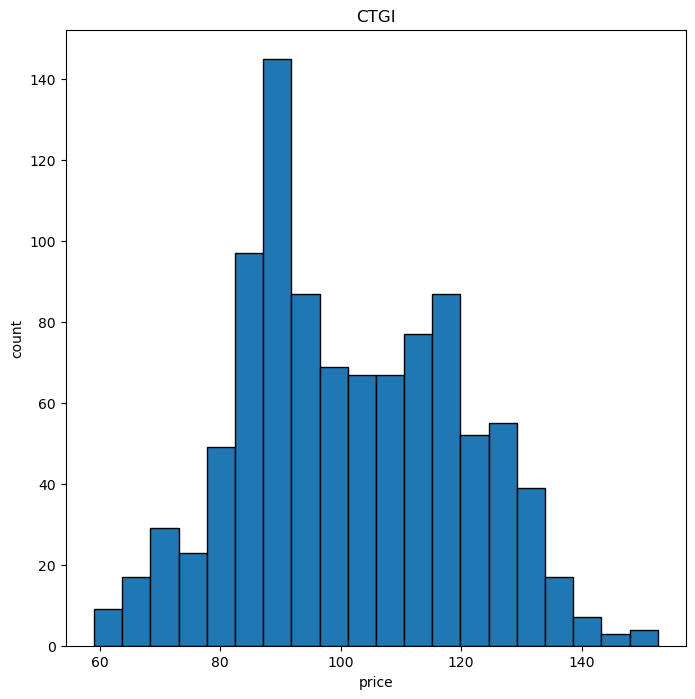

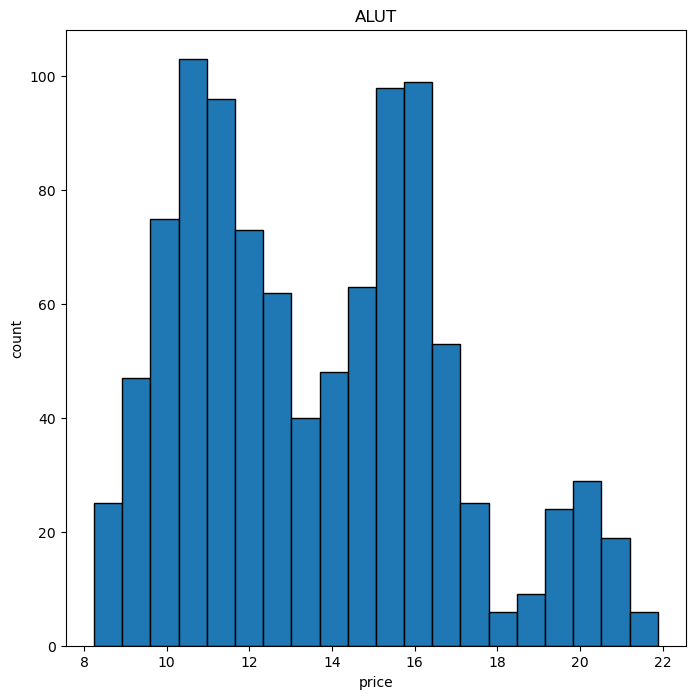

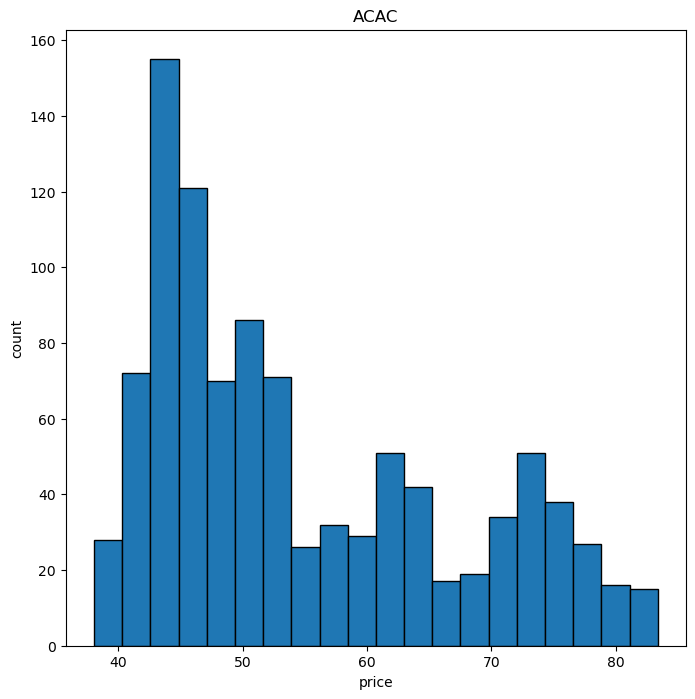

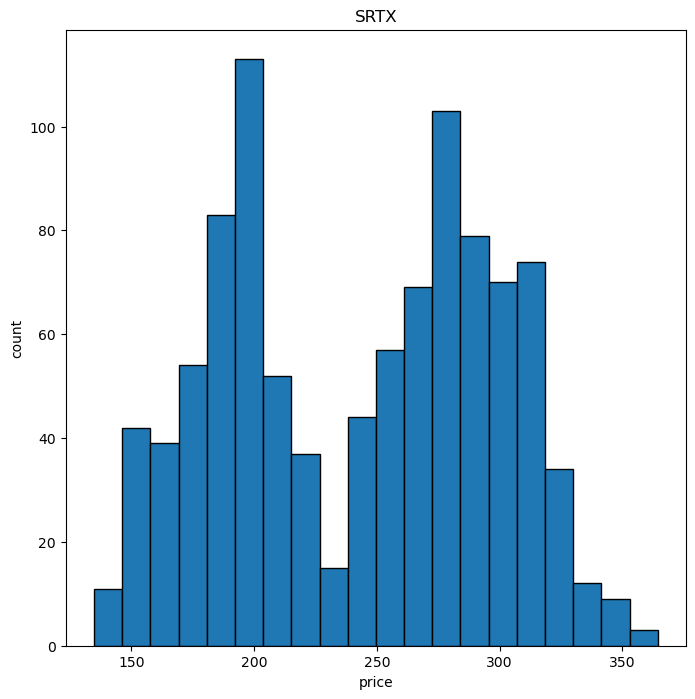

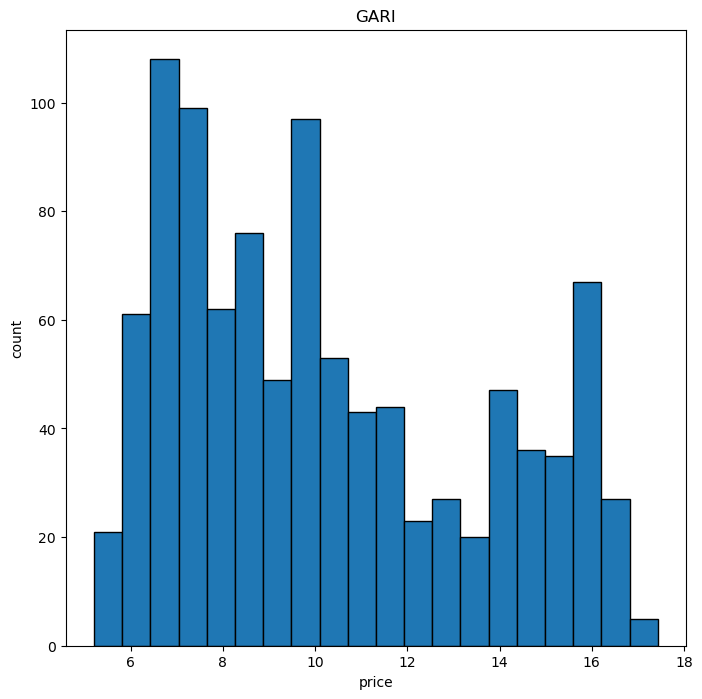

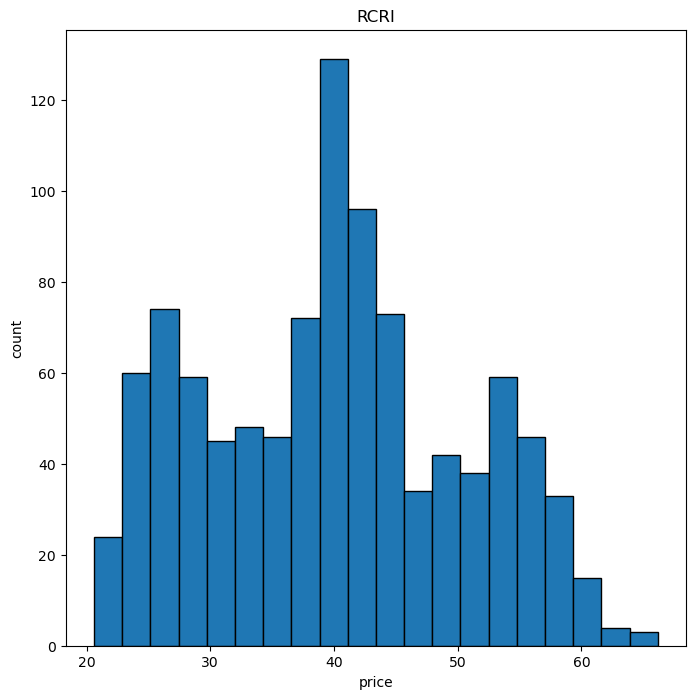

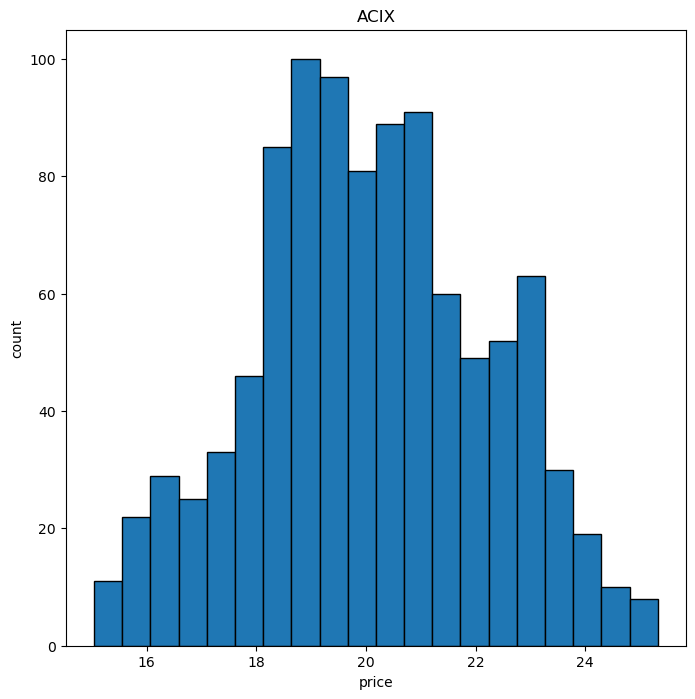

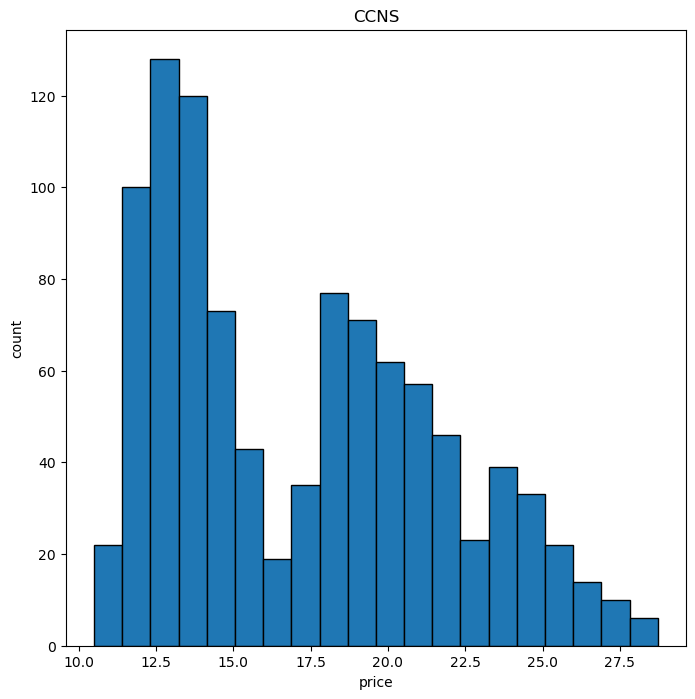

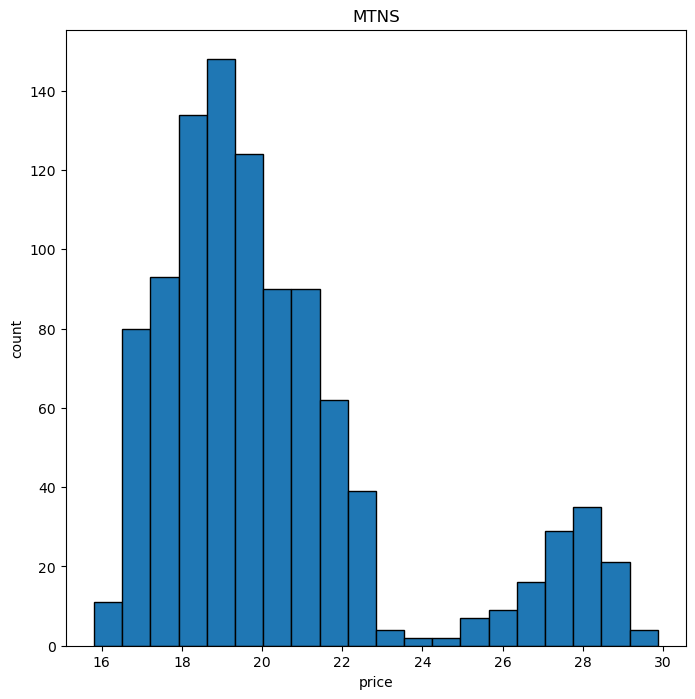

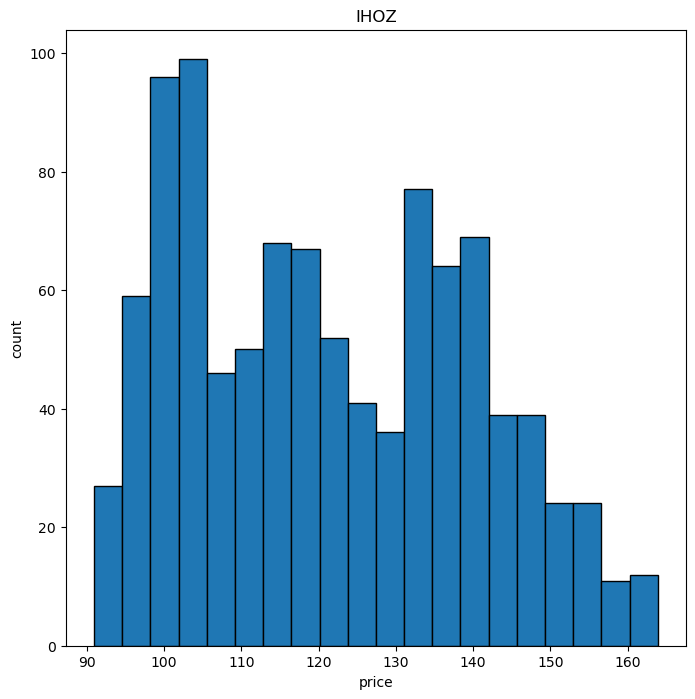

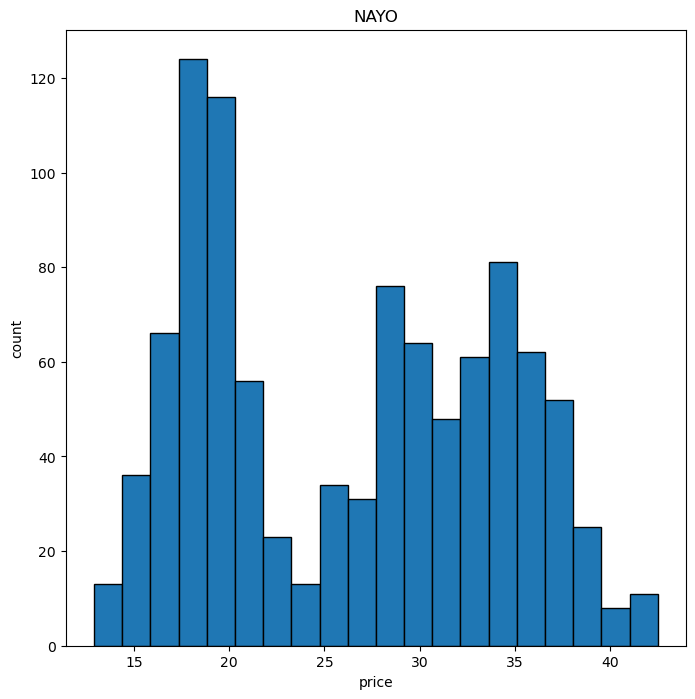

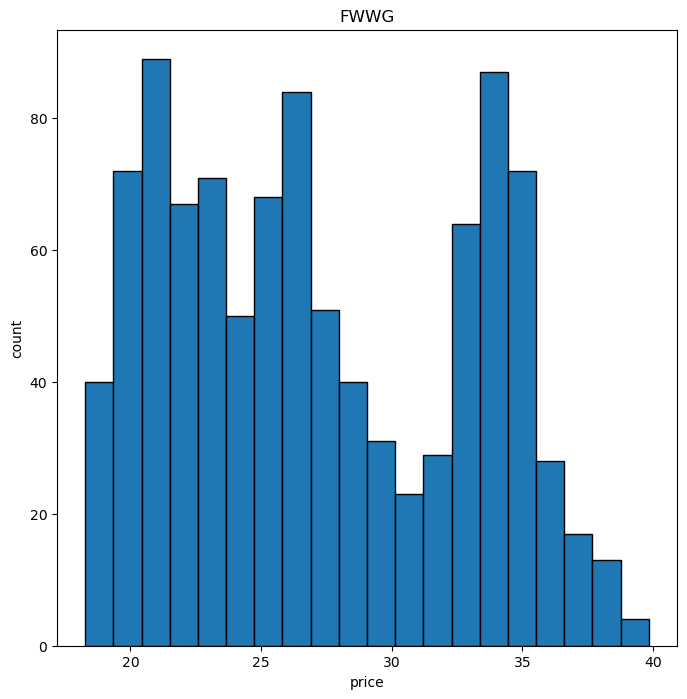

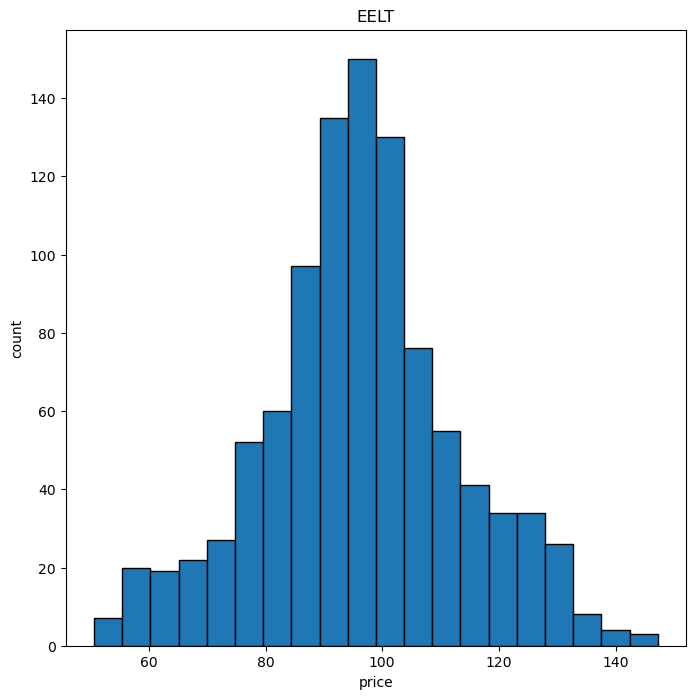

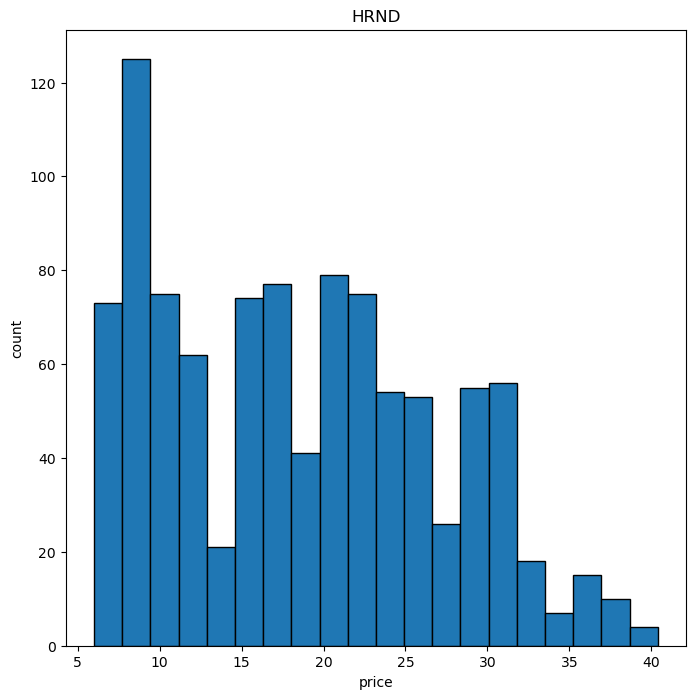

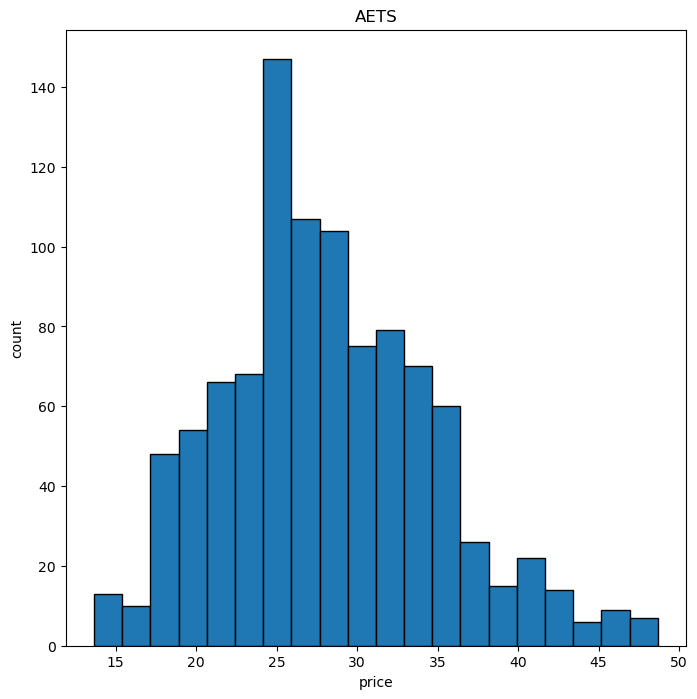

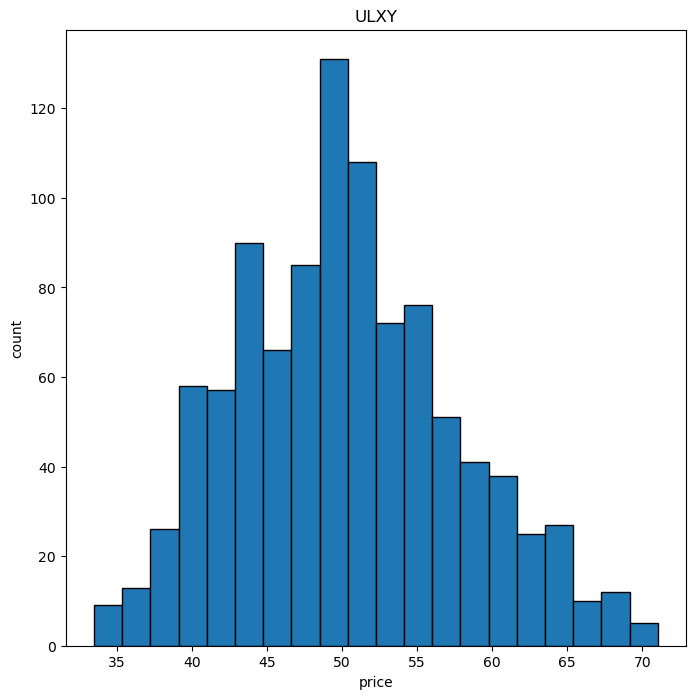

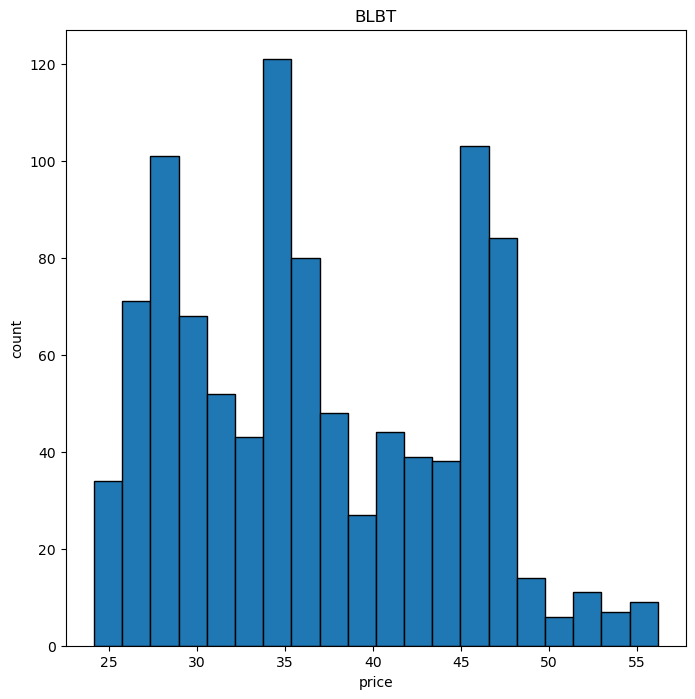

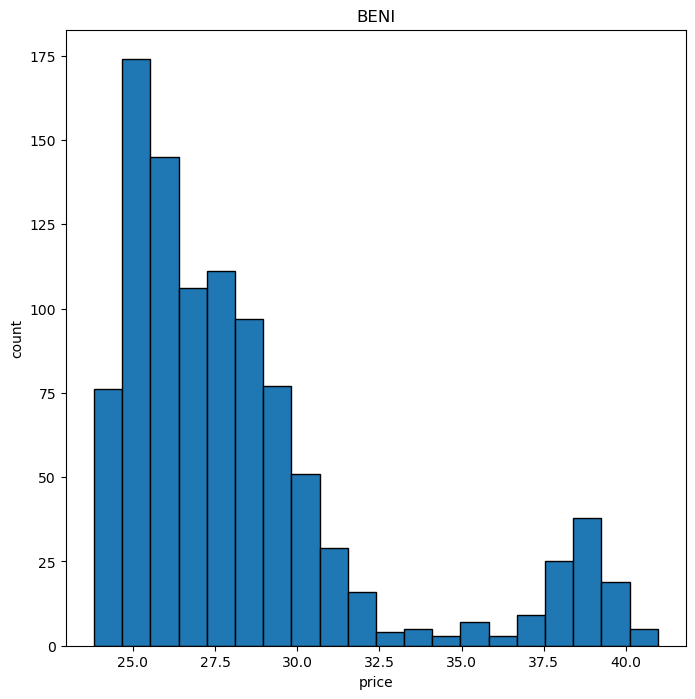

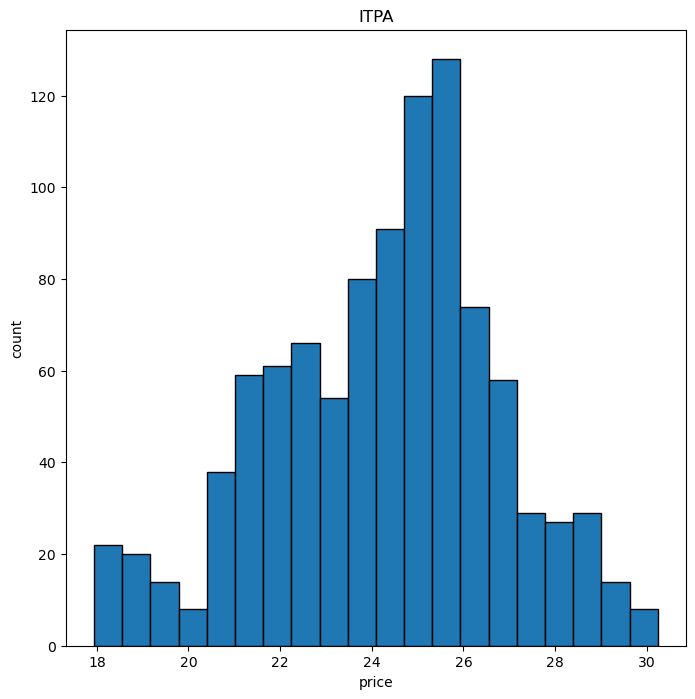

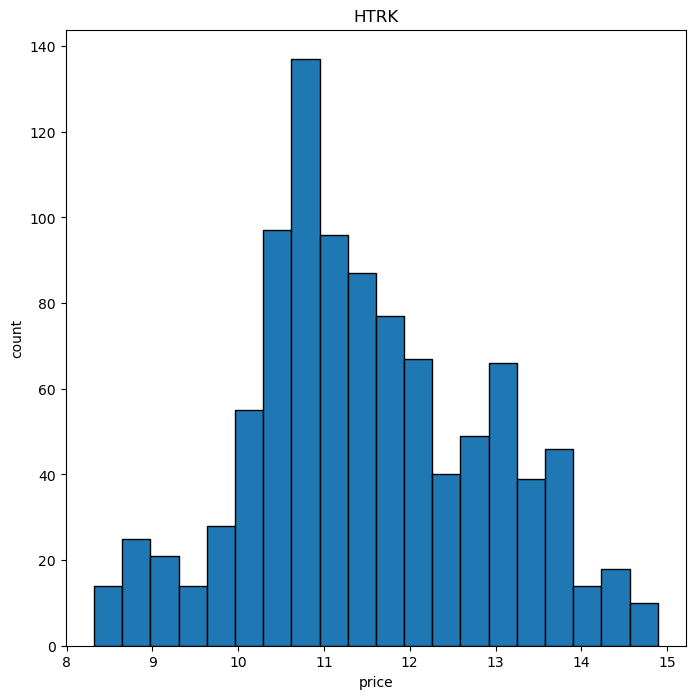

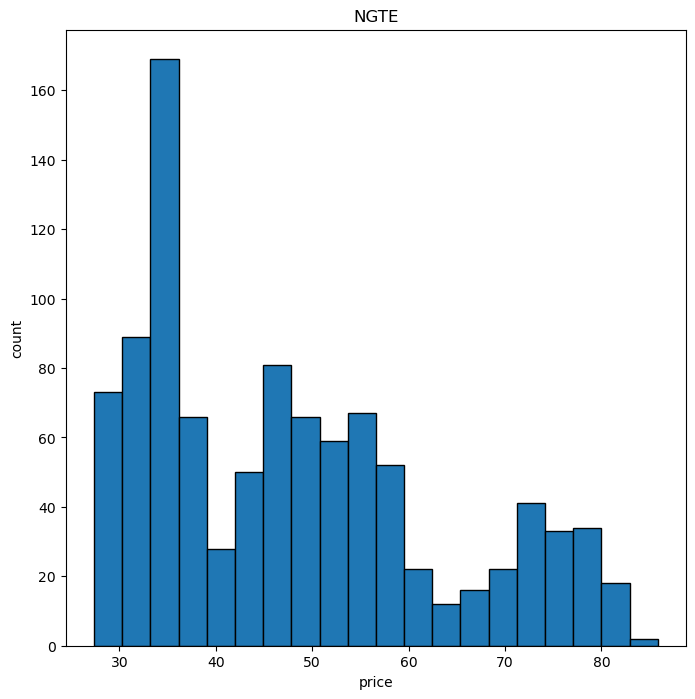

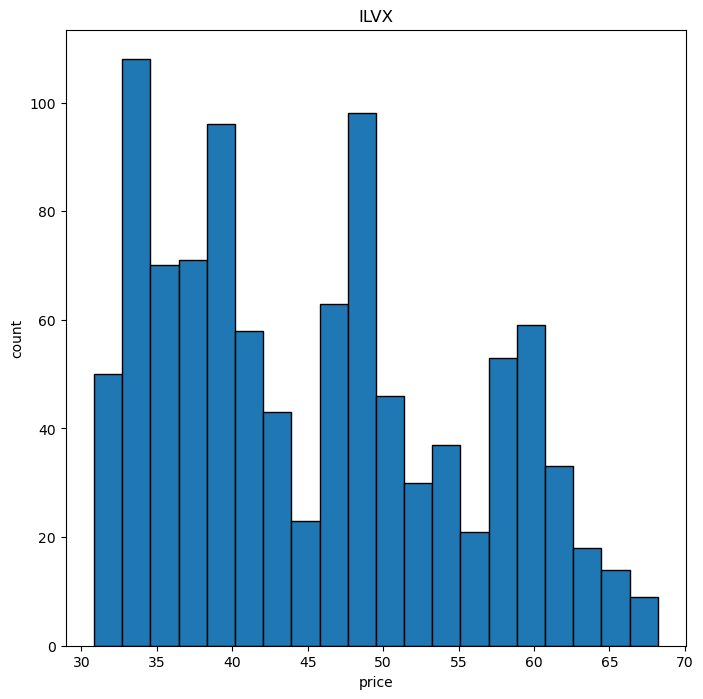

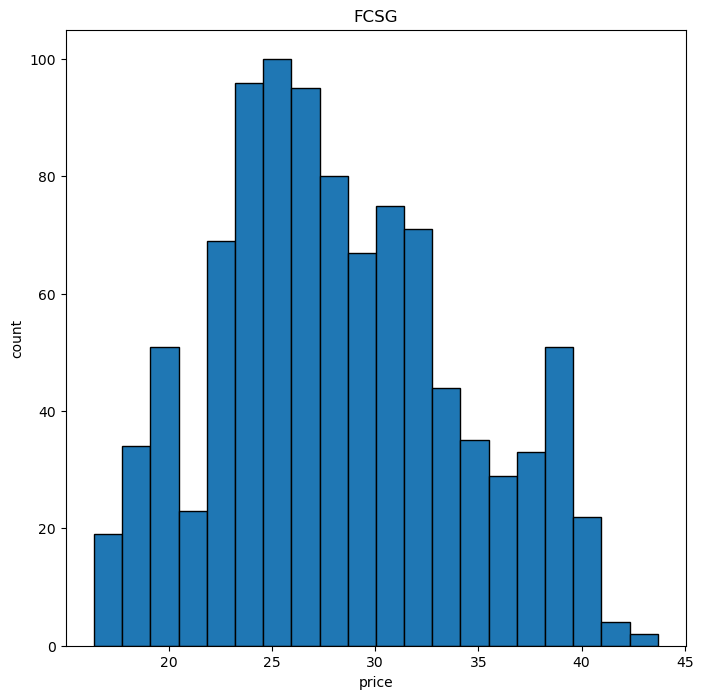

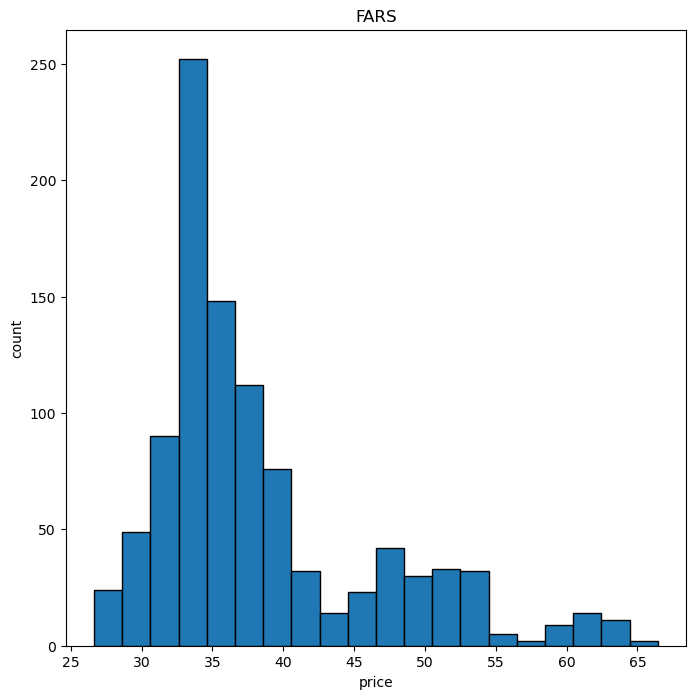

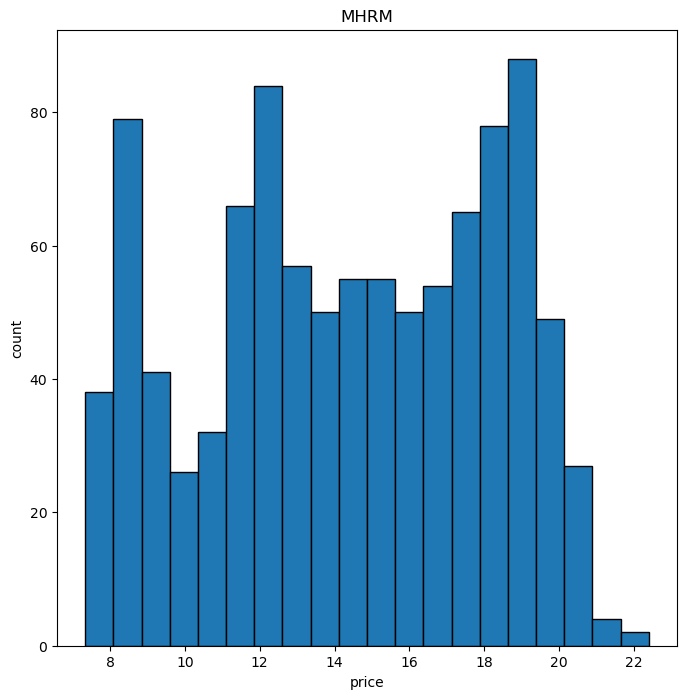

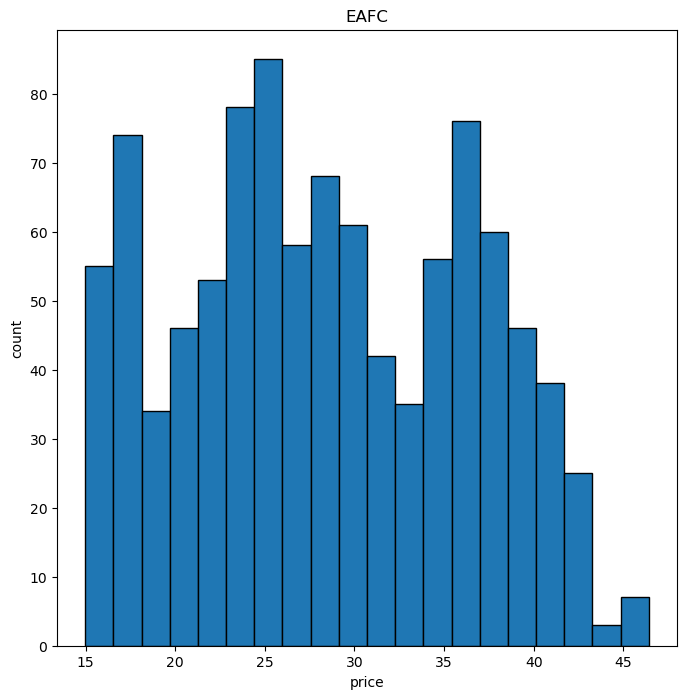

In [7]:
for instruments in prices.columns:
    plt.figure(figsize=(8,8))
    plt.hist(prices[instruments], edgecolor='black', bins=20)
    plt.title(instruments)
    plt.xlabel('price')
    plt.ylabel('count')
    plt.show()

SPLZ seems to be normally distributed mainly, BENI is bimodal and looking at its price data, seems to have a regime shift.  Seems that multiple peaks are indicative of regime shifts, so going to have to find a way to combat that regime shift somehow, and detect its onset.  Perhaps the key to regime shift detection is in other instruments

Prices Vs Time

On The Plotly Express Plots file, will create an HTML for easier observation

ADF Test, checks for stationarity, results are on ADF_ACF_tests script, notebook had an issue:
For ADF Test: the following stocks were interesting and had notable results:
For constant regression component used:
MTNS, NAYO, EELT, ULXY, BENI.
For constant and trend regression component used (stationary around a trending mean):
NAYO, MTNS, GARI, RTTH

NAYO seems to be mean reverting around some moving/trending target while MTNS is mean reverting around some constant mean.  

<Axes: >

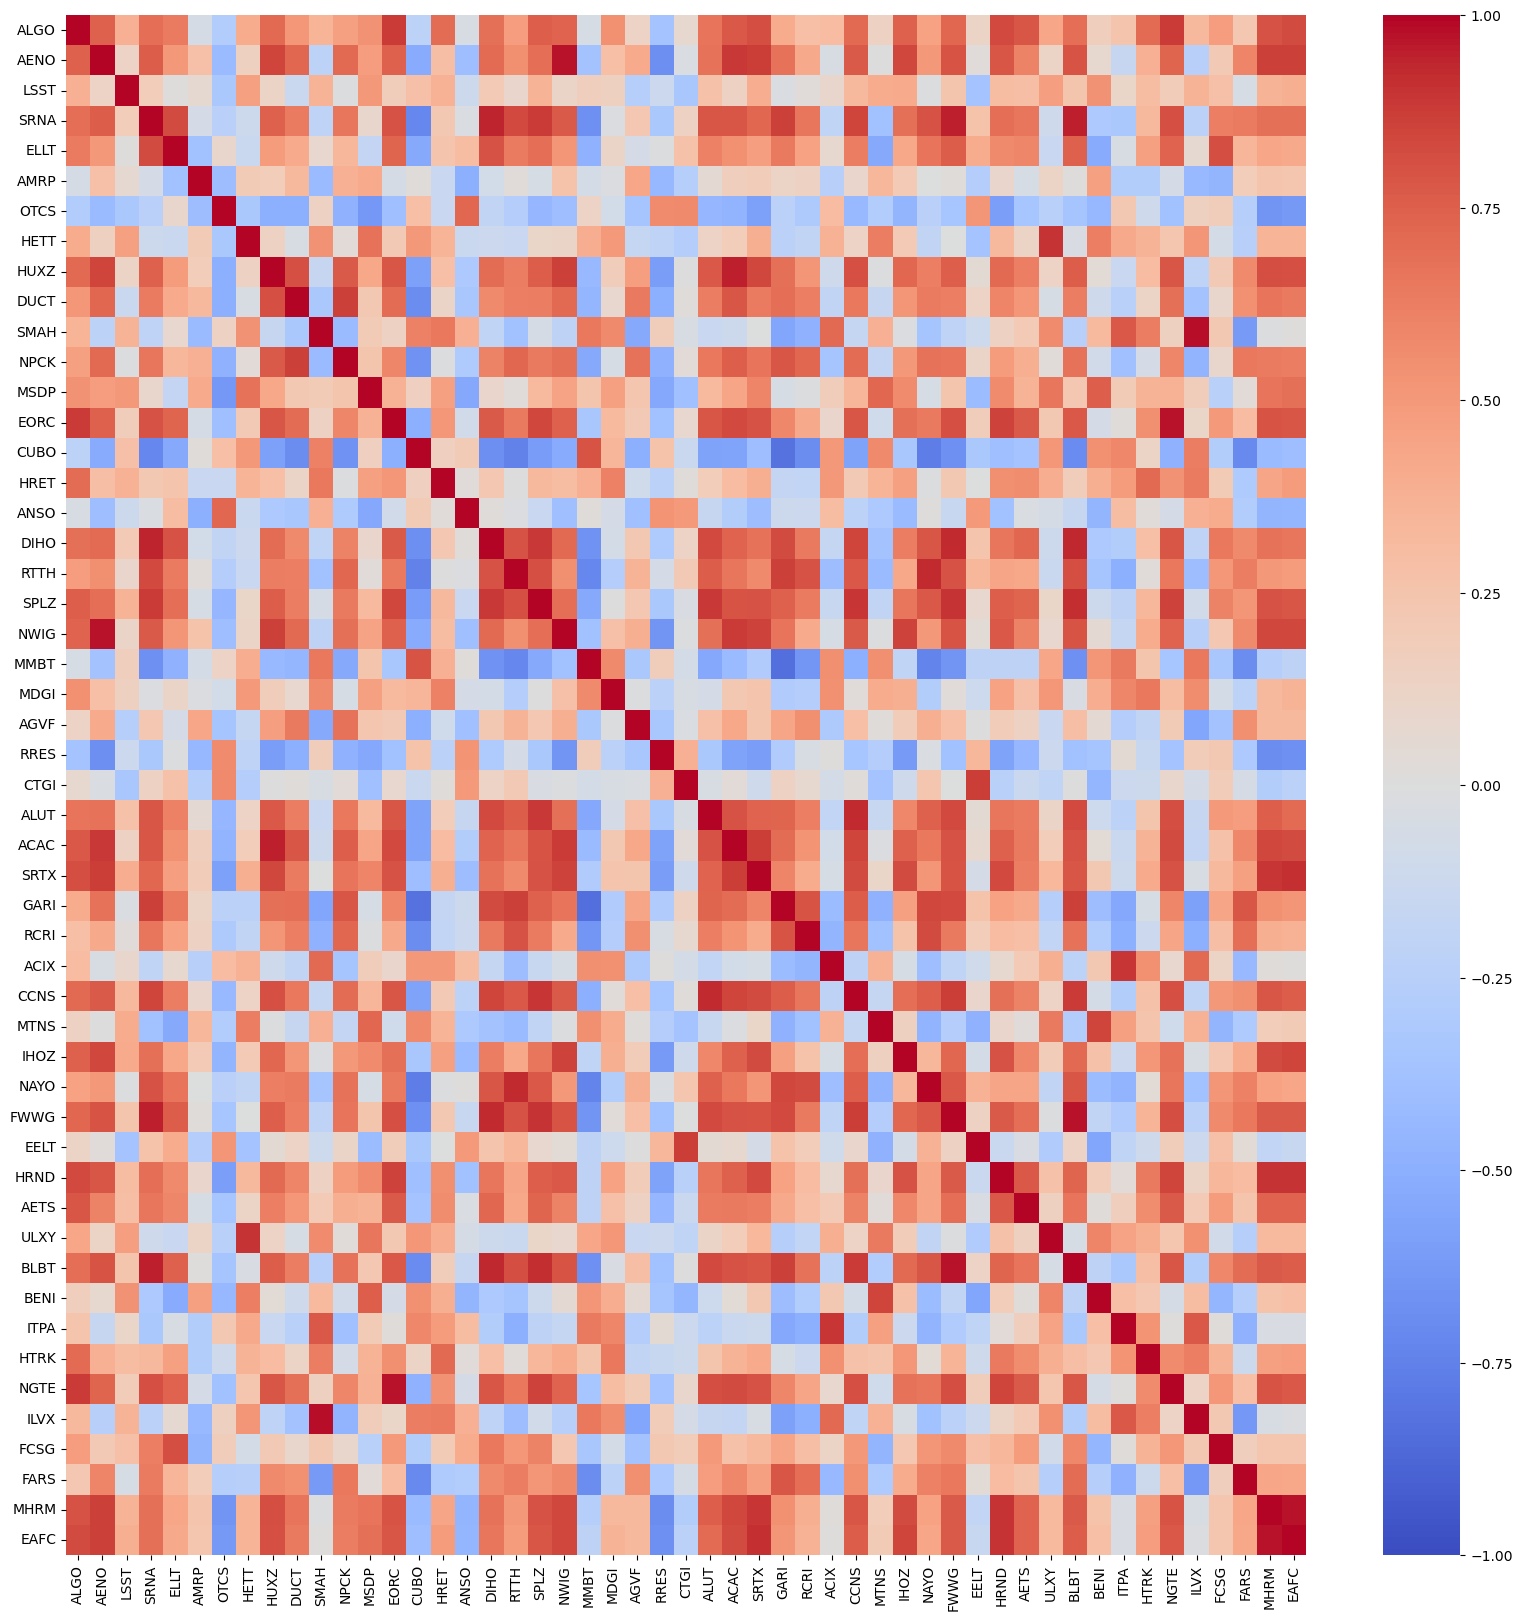

In [8]:
matrix1 = np.log(prices).corr('spearman')
plt.figure(figsize=(20,20))
sns.heatmap(data=matrix1, cmap='coolwarm', vmin=-1, vmax=1)


<Axes: >

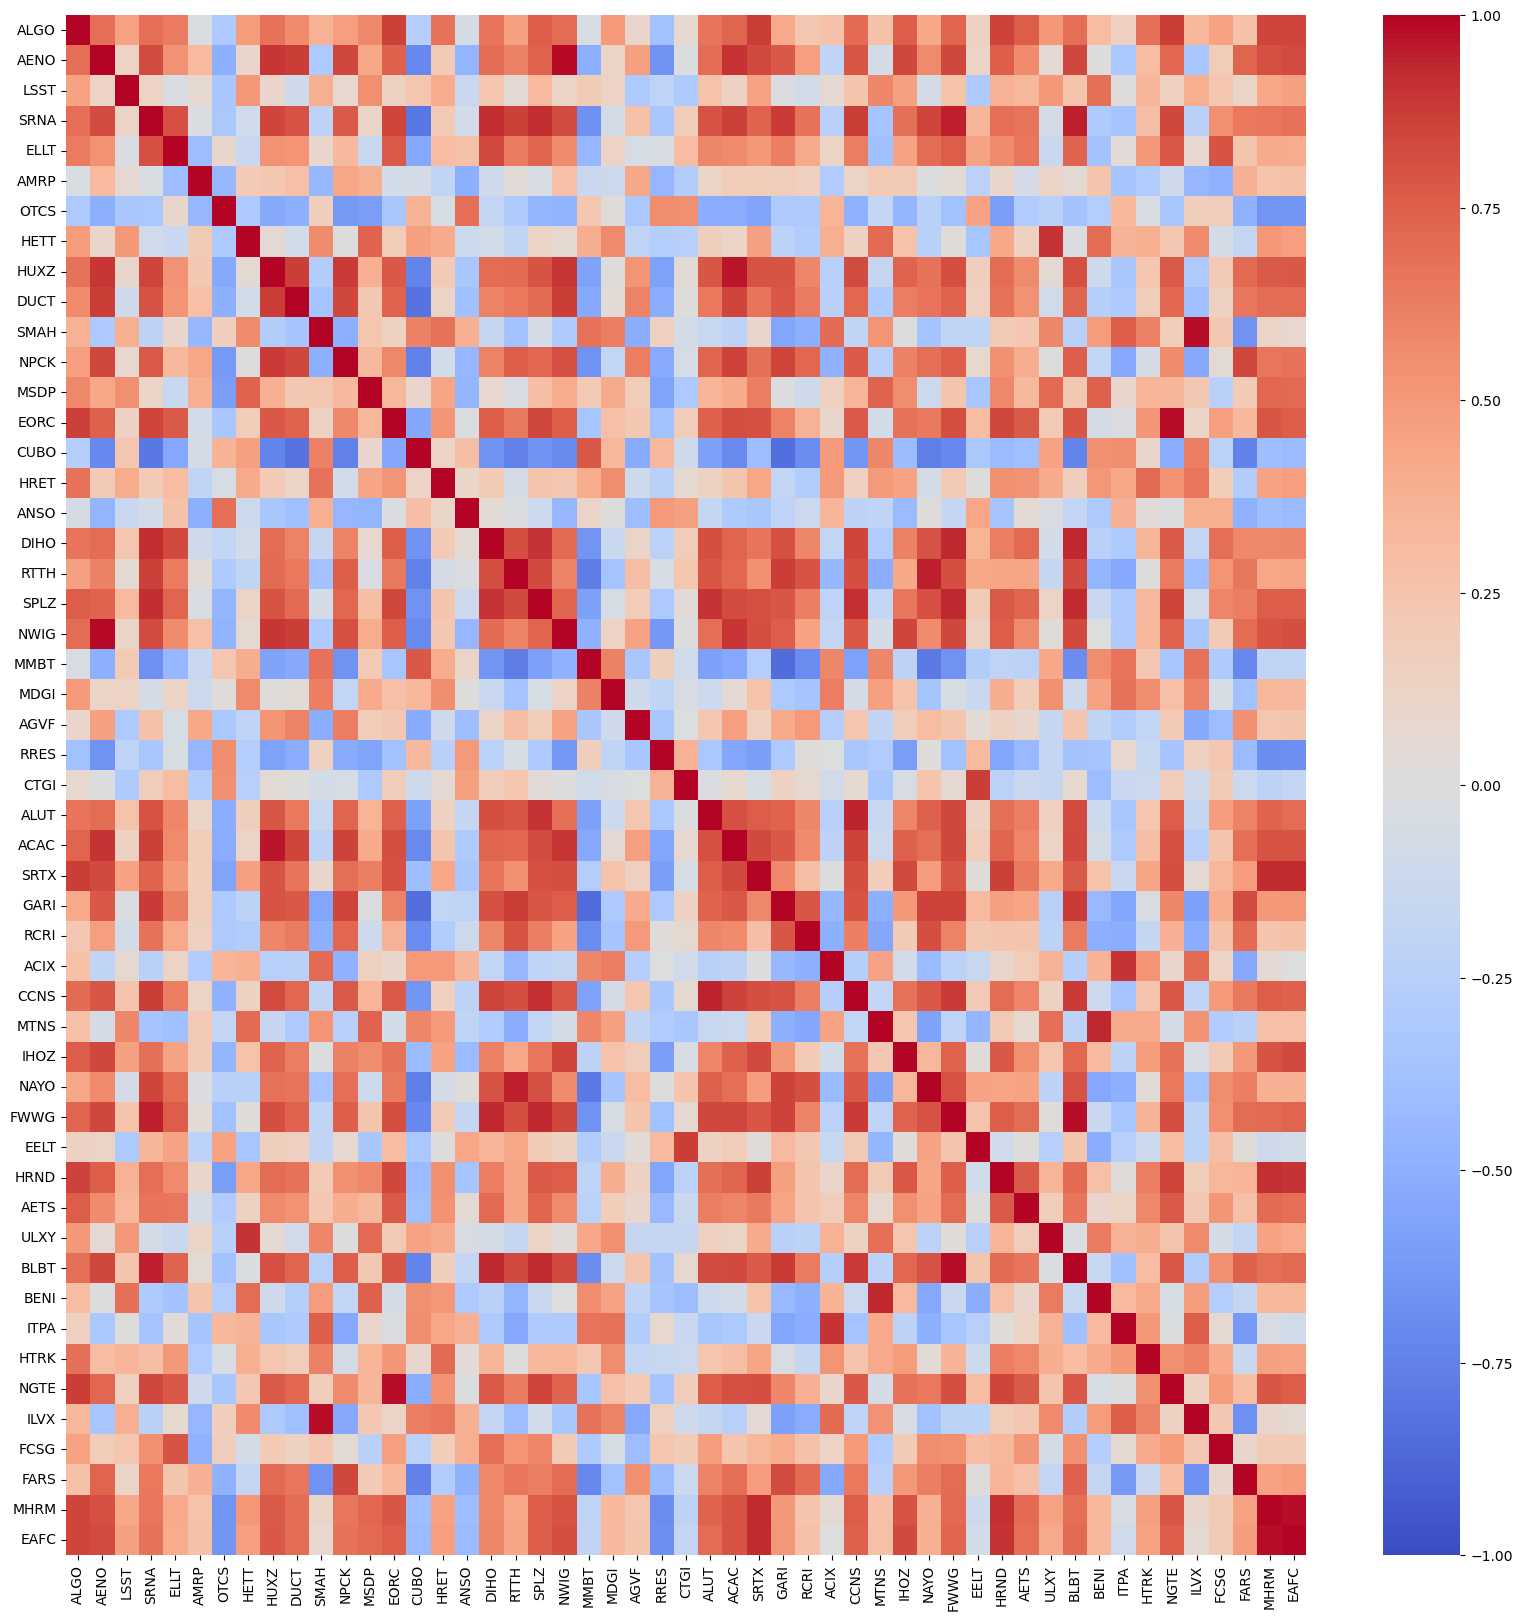

In [9]:
matrix2 = np.log(prices).corr('pearson')
plt.figure(figsize=(20,20))
sns.heatmap(data=matrix2, cmap='coolwarm', vmin=-1, vmax=1)

<Axes: >

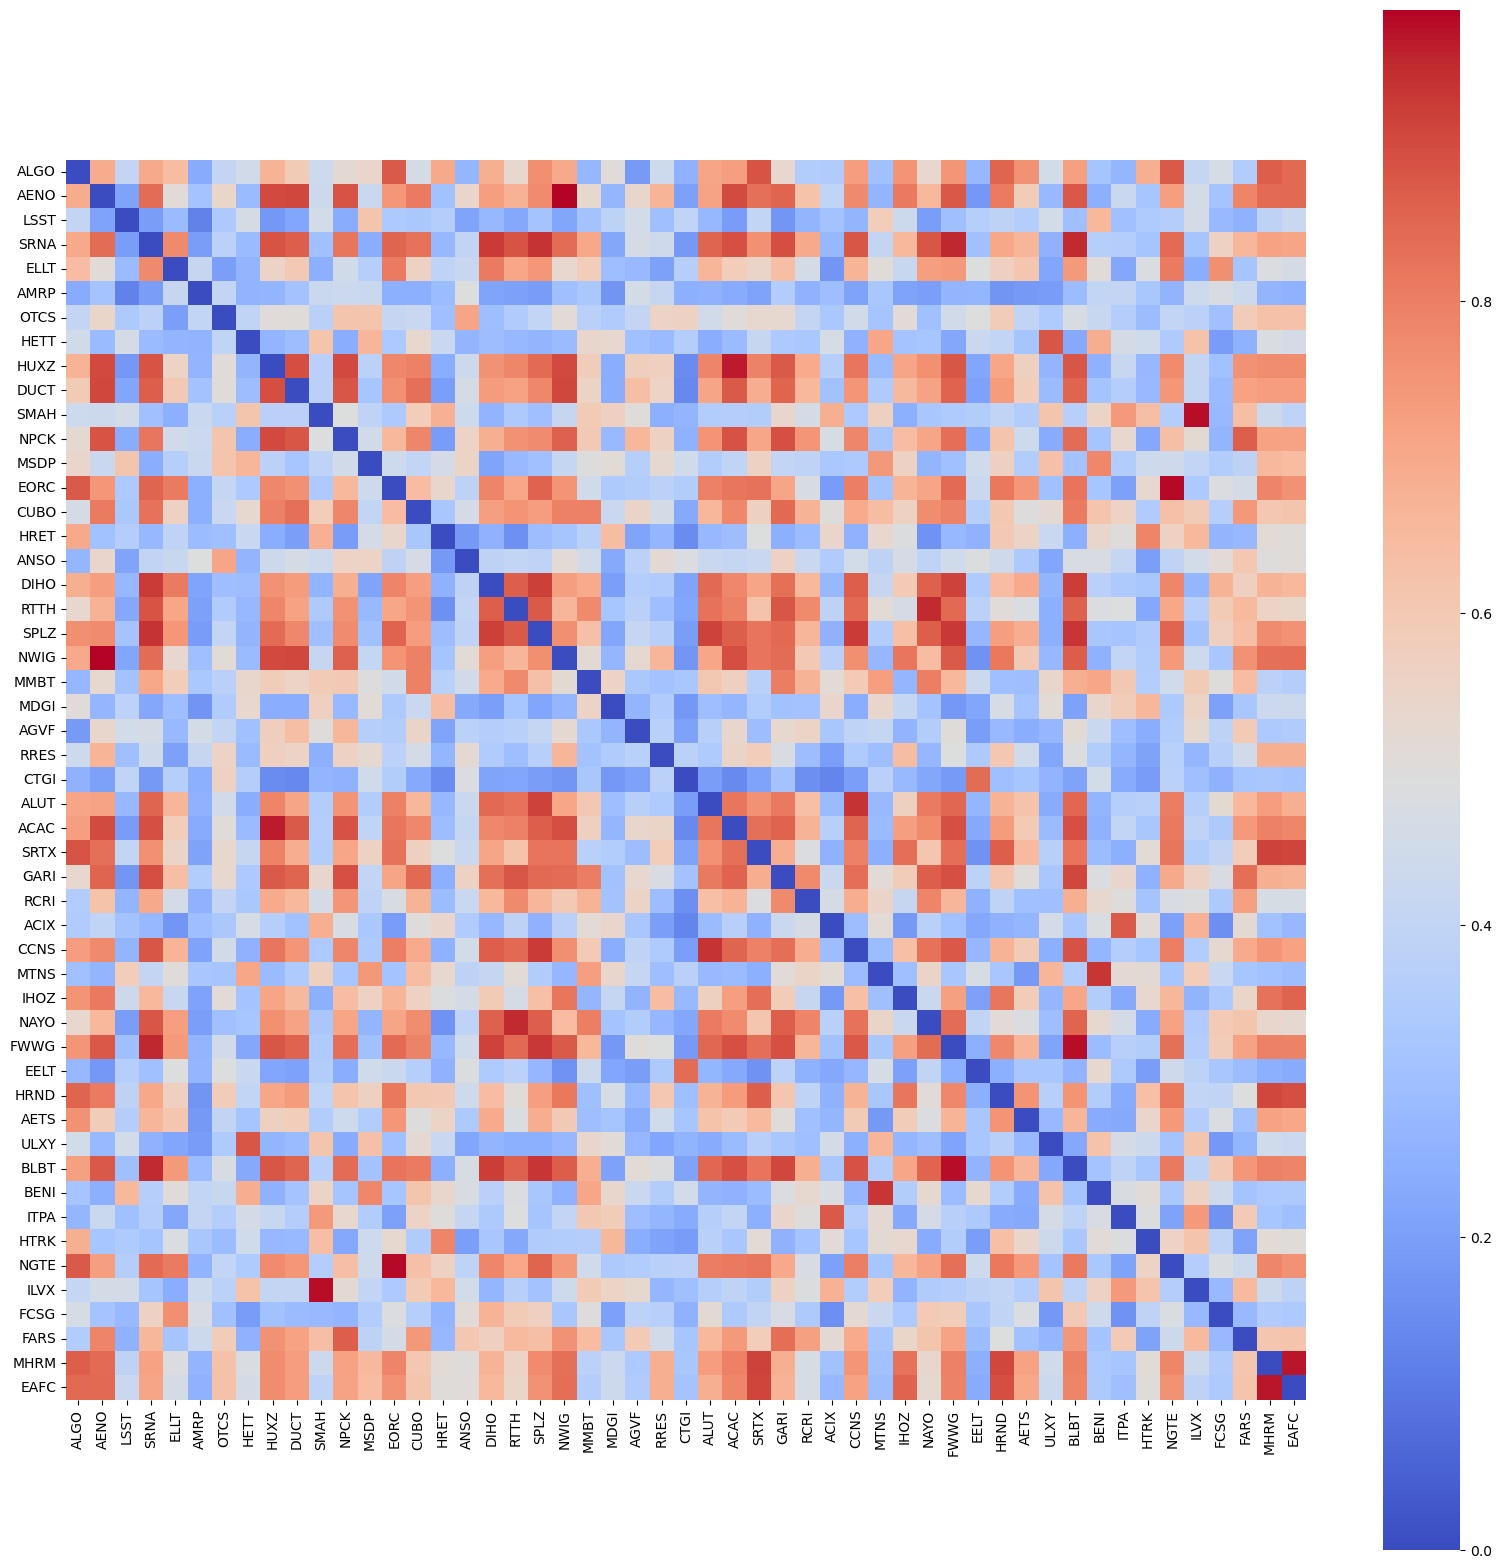

In [10]:
dcorr_df = pd.read_csv('dcorr_df.csv')
from scipy.spatial.distance import squareform
import pandas as pd

condensed = dcorr_df.sort_values(['instrument_1', 'instrument_2'])['distance_corr'].values
dcorr_matrix = squareform(condensed)
n = 51
dcorr_df_square = pd.DataFrame(dcorr_matrix,
                                 index=[f'{prices.columns.values[k]}' for k in range(n)],
                                 columns=[f'{prices.columns.values[k]}' for k in range(n)])

np.fill_diagonal(dcorr_matrix, 1.0)
plt.figure(figsize=(20,20))
sns.heatmap(dcorr_df_square, cmap='coolwarm', square=True)

<Axes: >

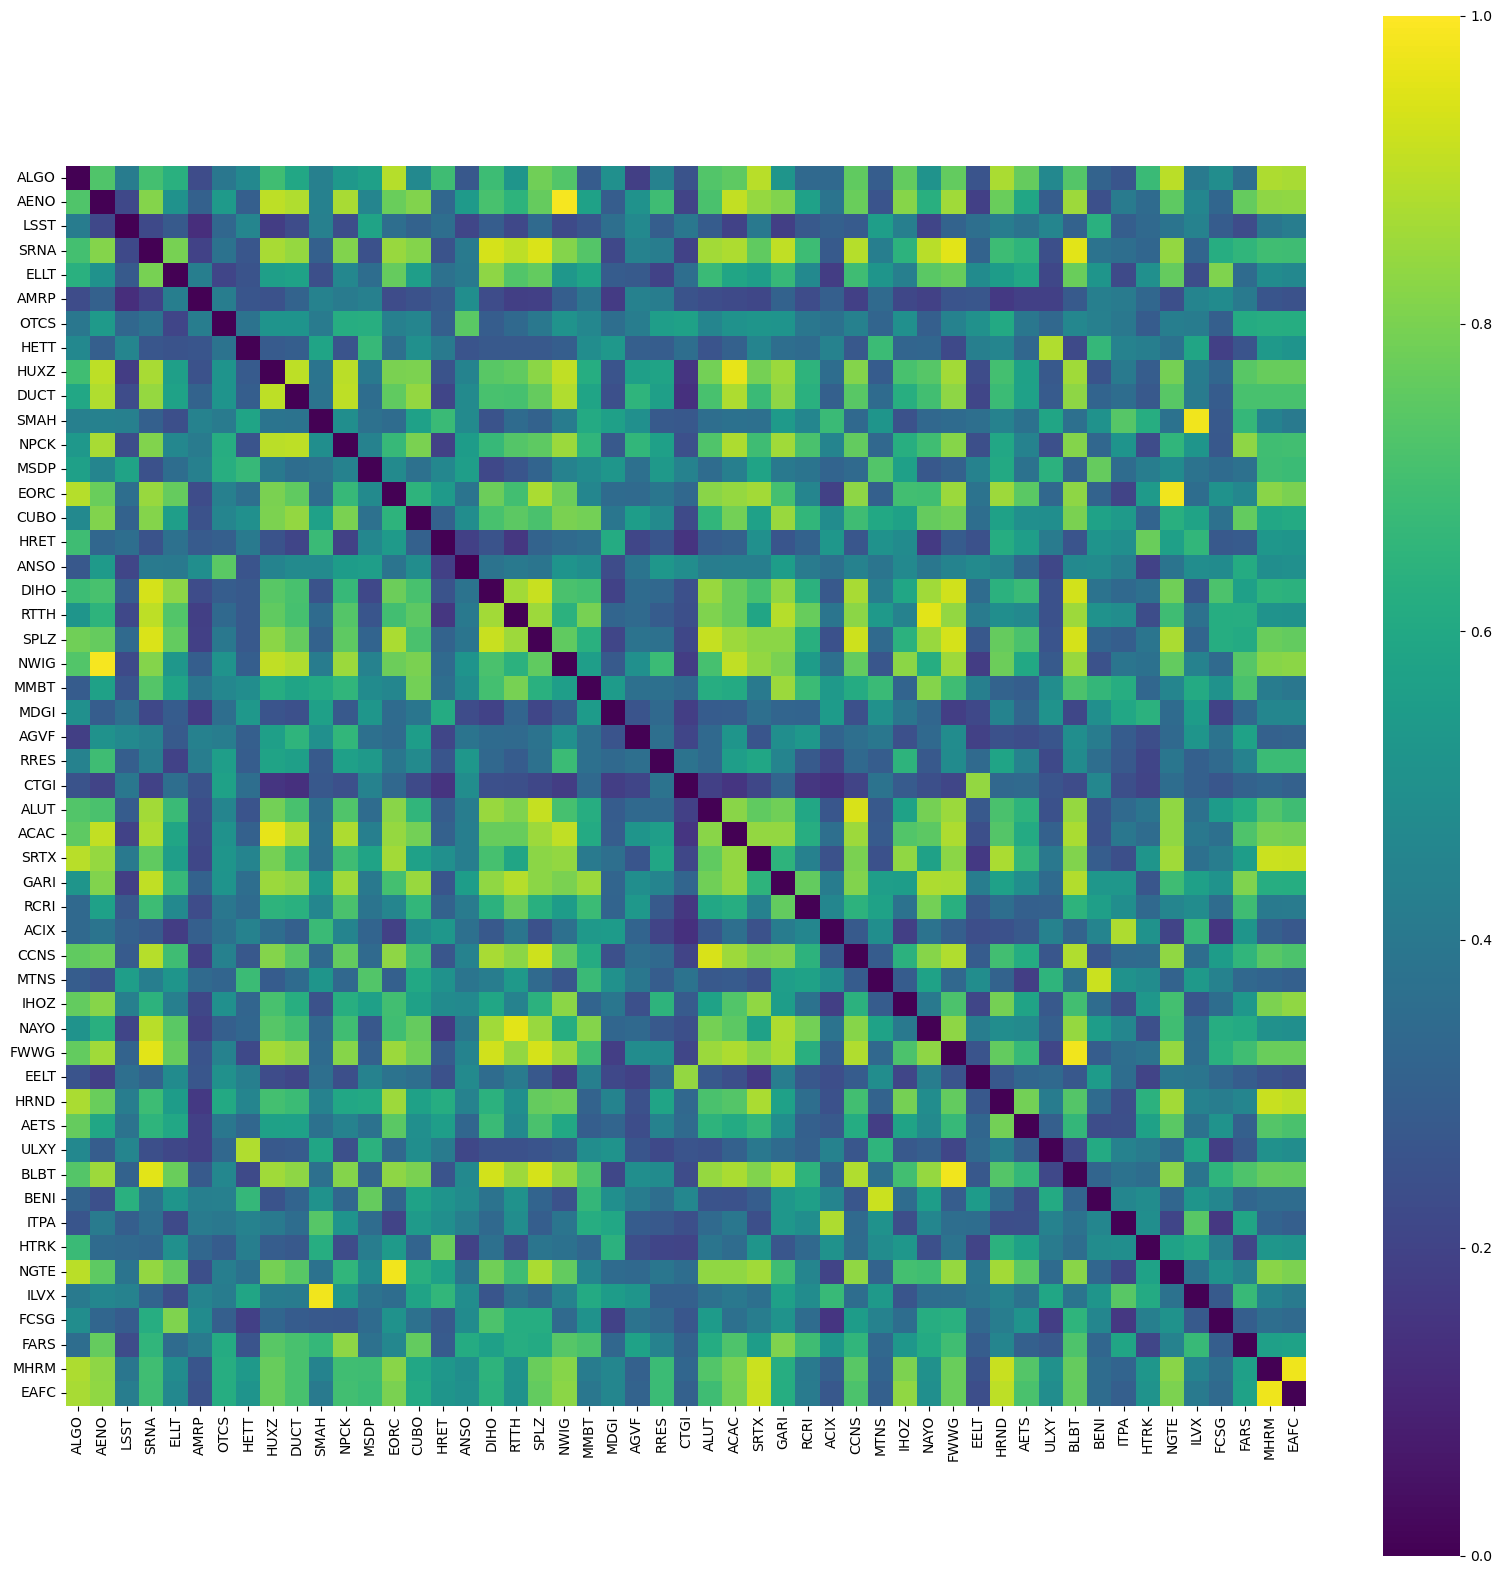

In [11]:
dcorr_returns = pd.read_csv('log_price_dcorr_df.csv')
condensed = dcorr_returns.sort_values(['instrument_1', 'instrument_2'])['distance_corr'].values
dcorr_matrix = squareform(condensed)
n = 51
dcorr_df_square = pd.DataFrame(dcorr_matrix,
                                 index=[f'{prices.columns.values[k]}' for k in range(n)],
                                 columns=[f'{prices.columns.values[k]}' for k in range(n)])

np.fill_diagonal(dcorr_matrix, 1.0)
plt.figure(figsize=(20,20))
sns.heatmap(dcorr_df_square, cmap='viridis', square=True, vmin=0.0, vmax=1.0)


In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal

prices = np.log(pd.read_csv("prices.csv").iloc[:500])

for a in prices.columns:
    # Use returns rather than prices
    x = prices[a].to_numpy()
    y = prices['MHRM'].to_numpy()

    # Remove the mean
    x = x - np.mean(x)
    y = y - np.mean(y)

    # Compute normalized cross-correlation
    corr = signal.correlate(x, y, mode="full")
    lags = signal.correlation_lags(len(x), len(y), mode="full")
    corr = corr / (len(x) * np.std(x) * np.std(y))

    # Find the strongest correlation (positive or negative)
    idx = np.argmax(np.abs(corr))

    print(f"{a} vs MHRM")
    print(f"Best lag: {lags[idx]}")
    print(f"Correlation: {corr[idx]:.4f}")

    if lags[idx] > 0:
        print(f"→ MMBT leads {a} by {lags[idx]} days")
    elif lags[idx] < 0:
        print(f"→ {a} leads MMBT by {-lags[idx]} days")
    else:
        print("→ No lead-lag relationship (peak at lag 0)")

    # plt.figure(figsize=(8, 4))
    # plt.plot(lags, corr)
    # plt.axvline(0, color="black", linestyle="--")
    # plt.axhline(0, color="grey", linestyle=":")
    # plt.title(f"Cross-correlation: {a} vs MMBT")
    # plt.xlabel("Lag (days)")
    # plt.ylabel("Normalized cross-correlation")
    # plt.grid(True)
    # plt.show()



ALGO vs MHRM
Best lag: 0
Correlation: 0.6682
→ No lead-lag relationship (peak at lag 0)
AENO vs MHRM
Best lag: 0
Correlation: 0.9100
→ No lead-lag relationship (peak at lag 0)
LSST vs MHRM
Best lag: -151
Correlation: 0.5518
→ LSST leads MMBT by 151 days
SRNA vs MHRM
Best lag: 0
Correlation: 0.8163
→ No lead-lag relationship (peak at lag 0)
ELLT vs MHRM
Best lag: -159
Correlation: -0.6321
→ ELLT leads MMBT by 159 days
AMRP vs MHRM
Best lag: -77
Correlation: 0.7022
→ AMRP leads MMBT by 77 days
OTCS vs MHRM
Best lag: 0
Correlation: -0.6740
→ No lead-lag relationship (peak at lag 0)
HETT vs MHRM
Best lag: -365
Correlation: -0.3982
→ HETT leads MMBT by 365 days
HUXZ vs MHRM
Best lag: 0
Correlation: 0.8735
→ No lead-lag relationship (peak at lag 0)
DUCT vs MHRM
Best lag: 0
Correlation: 0.8819
→ No lead-lag relationship (peak at lag 0)
SMAH vs MHRM
Best lag: -94
Correlation: -0.7543
→ SMAH leads MMBT by 94 days
NPCK vs MHRM
Best lag: 0
Correlation: 0.8099
→ No lead-lag relationship (peak at l

Price Level PCA

In [13]:
from sklearn.decomposition import PCA

pca = PCA(n_components=8)
pca.fit(np.log(prices))
print(f"Entire price series variance ratio: {pca.explained_variance_ratio_}")

Entire price series variance ratio: [0.61655557 0.19404015 0.04583514 0.02869813 0.02379652 0.02057369
 0.01129118 0.00945278]


In [14]:
loadings = pca.components_.T
loading_df = pd.DataFrame(data=loadings, columns=[f"PC{i}" for i in range(1,9)], index=prices.columns)
print(loading_df)

           PC1       PC2       PC3       PC4       PC5       PC6       PC7  \
ALGO  0.027103  0.062475 -0.047536 -0.010697  0.034280 -0.008943  0.017214   
AENO  0.188805  0.046312  0.123883 -0.047081  0.055661  0.068151 -0.079137   
LSST -0.000161 -0.087991 -0.174911  0.048323  0.160606  0.143452 -0.143019   
SRNA  0.118093  0.113498 -0.027391  0.033655  0.139154  0.022542 -0.217416   
ELLT -0.010773  0.217508  0.101590 -0.057057 -0.013129 -0.023433  0.011936   
AMRP  0.139681 -0.235308  0.210227  0.253658 -0.080960 -0.110687  0.135581   
OTCS -0.241955  0.294711  0.037570  0.183417  0.084222 -0.041728  0.181732   
HETT  0.001255 -0.015960 -0.117404 -0.145664 -0.206503 -0.146729  0.050379   
HUXZ  0.151229  0.047131 -0.107702 -0.038018  0.098022 -0.094183 -0.123384   
DUCT  0.257159  0.170643  0.193511 -0.114238  0.127213  0.089272  0.090974   
SMAH -0.106676  0.204923 -0.201445 -0.108038 -0.006873 -0.051537 -0.233657   
NPCK  0.369252 -0.143135 -0.153623 -0.095396  0.172764 -0.185654

In [15]:
for i in range(1,9):
    pc = loading_df[f'PC{i}'].sort_values(ascending=False)
    print(f'PC{i}')
    print(pc.head())
    print()

PC1
NPCK    0.369252
HRND    0.346652
MHRM    0.259230
DUCT    0.257159
GARI    0.233050
Name: PC1, dtype: float64

PC2
EORC    0.331369
HRND    0.303947
OTCS    0.294711
NGTE    0.282548
MMBT    0.227644
Name: PC2, dtype: float64

PC3
HRND    0.340231
AMRP    0.210227
DUCT    0.193511
NWIG    0.153934
AENO    0.123883
Name: PC3, dtype: float64

PC4
AETS    0.540203
DIHO    0.364111
AMRP    0.253658
ANSO    0.193269
OTCS    0.183417
Name: PC4, dtype: float64

PC5
MMBT    0.377955
RCRI    0.279654
HRET    0.273180
RTTH    0.189123
CTGI    0.186557
Name: PC5, dtype: float64

PC6
MMBT    0.367222
CCNS    0.310440
FCSG    0.302914
MHRM    0.250440
EAFC    0.200088
Name: PC6, dtype: float64

PC7
RRES    0.301922
RCRI    0.249683
NAYO    0.248957
GARI    0.243003
EELT    0.213435
Name: PC7, dtype: float64

PC8
HRND    0.358330
RCRI    0.283214
NAYO    0.242847
MTNS    0.234504
ILVX    0.196432
Name: PC8, dtype: float64



In [16]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

normalised_prices = scaler.fit_transform(prices)
scores = pca.fit_transform(normalised_prices)
